# Introduction

## dcd frames count

In [13]:
def count_frames(psf, dcd):
    import MDAnalysis as mda
    u = mda.Universe(psf, dcd)
    return len(u.trajectory)

psf = '/mnt/hdd/jeff/dataset/mdgen-collagen/dataset/WT-dataset/raw/100ns/pdbxtc/protein-r1/1.pdb'
dcd = '/mnt/hdd/jeff/dataset/mdgen-collagen/dataset/WT-dataset/raw/100ns/pdbxtc/protein-r1/1.xtc'
count_frames(psf, dcd)

10000

## concate dcd

In [ ]:
def concat_dcd(pdb, dcd1, dcd2, out_dcd):
    import os
    import MDAnalysis as mda
    from MDAnalysis.coordinates.DCD import DCDWriter

    # ---------- 分別讀兩條 trajectory ----------
    u1 = mda.Universe(pdb, dcd1)
    u2 = mda.Universe(pdb, dcd2)

    # ---------- 檢查原子數是否一致 ----------
    if u1.atoms.n_atoms != u2.atoms.n_atoms:
        raise ValueError(
            f"兩個 DCD 原子數不同，不能直接接起來："
            f"{u1.atoms.n_atoms} vs {u2.atoms.n_atoms}"
        )

    # ---------- 寫出合併後的 DCD ----------
    with DCDWriter(out_dcd, n_atoms=u1.atoms.n_atoms) as W:
        for ts in u1.trajectory:
            W.write(u1.atoms)

        for ts in u2.trajectory:
            W.write(u2.atoms)

## analysis

### rmsd

In [2]:
def plot_rmsd_multi_png(pdb_list, dcd_list, out_png, start, end, stride):
    import MDAnalysis as mda
    from MDAnalysis.analysis import align, rms
    import matplotlib.pyplot as plt
    import numpy as np

    plt.figure(figsize=(10, 5))

    for i, (pdb_path, dcd_path) in enumerate(zip(pdb_list, dcd_list)):
        u = mda.Universe(pdb_path, dcd_path)
        ref = mda.Universe(pdb_path, dcd_path)

        n_total = len(u.trajectory)
        real_end = n_total if end is None else min(end, n_total)
        frames = list(range(start, real_end, stride))

        if len(frames) == 0:
            raise ValueError(f"traj_{i+1} 在 start={start}, end={end}, stride={stride} 下沒有 frame")

        # reference 設成 start 那一幀
        ref.trajectory[frames[0]]

        # 先對齊到 reference(start frame)
        align.AlignTraj(
            u,
            ref,
            select="protein and name CA",
            in_memory=False
        ).run(start=frames[0], stop=real_end, step=stride)

        # 再算 RMSD
        R = rms.RMSD(
            u,
            ref,
            select="protein and name CA",
            ref_frame=0
        ).run(start=frames[0], stop=real_end, step=stride)

        arr = R.results.rmsd if hasattr(R, "results") else R.rmsd

        # arr[:,0] 通常是 trajectory frame index，但不同版本有時格式會不太一樣
        # 直接用我們自己的 frames 最穩
        x = np.array(frames[:len(arr)])
        y = arr[:, 2] / 10.0   # Å -> nm

        plt.plot(x, y, lw=2.0, alpha=0.95, label=f"traj_{i+1}")

    plt.xlabel("Frame", fontsize=13)
    plt.ylabel("RMSD (nm)", fontsize=13)
    plt.title("RMSD", fontsize=15)
    plt.ylim(0, 2)
    plt.grid(True, alpha=0.25)
    #plt.legend(frameon=False, fontsize=10)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close()

In [ ]:

pdb_list = ['/mnt/hdd/jeff/dataset/mdgen-collagen/dataset/mdgen/raw/protein/1ah7_A/1ah7_A.pdb']
xtc_list = ['/mnt/hdd/jeff/dataset/mdgen-collagen/dataset/mdgen/raw/protein/1ah7_A/1ah7_A_prod_R1_fit.xtc']
out_png = '/mnt/hdd/jeff/dataset/mdgen-collagen/dataset/WT-dataset/inference/analysis/1ah7-atlas.png'
start=0
end=10000
stride = 40
plot_rmsd_multi_png(pdb_list, xtc_list, out_png,
                        start,
                        end,stride)

### pca 

In [6]:
def plot_pca_multi_png(pdb_list, dcd_list, out_png, start, end, stride):
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA
    import MDAnalysis as mda
    from MDAnalysis.analysis import align

    all_xyz = []
    traj_ids = []
    frame_ids = []

    for i, (pdb_path, dcd_path) in enumerate(zip(pdb_list, dcd_list)):
        u = mda.Universe(pdb_path, dcd_path)
        ca = u.select_atoms("protein and name CA")

        if len(ca) == 0:
            raise ValueError(f"traj_{i+1} 沒有選到 CA 原子")

        # 先決定實際會取到哪些 frame
        n_frames_total = len(u.trajectory)
        real_end = n_frames_total if end is None else min(end, n_frames_total)
        frame_range = list(range(start, real_end, stride))

        if len(frame_range) == 0:
            raise ValueError(f"traj_{i+1} 在 start={start}, end={end}, stride={stride} 下沒有 frame")

        # 先抓 reference = 切出來後的第 0 幀（也就是原本的 start 幀）
        u.trajectory[frame_range[0]]
        ref_pos = ca.positions.copy()

        xyz_list = []

        # 逐幀讀取、對齊到 ref_pos、存 CA 座標
        for fr in frame_range:
            u.trajectory[fr]

            # Kabsch alignment：把目前這一幀的 CA 對齊到 reference CA
            mobile = ca.positions.copy()
            aligned = align.rotation_matrix(mobile - mobile.mean(axis=0),
                                            ref_pos - ref_pos.mean(axis=0))[0]

            mobile_center = mobile.mean(axis=0)
            ref_center = ref_pos.mean(axis=0)

            mobile_aligned = (mobile - mobile_center) @ aligned.T + ref_center
            xyz_list.append(mobile_aligned.reshape(-1))

        xyz = np.array(xyz_list)   # shape = (T, Nca*3)

        all_xyz.append(xyz)
        traj_ids.extend([i] * xyz.shape[0])
        frame_ids.extend(frame_range)

    X = np.concatenate(all_xyz, axis=0)

    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)

    traj_ids = np.array(traj_ids)
    frame_ids = np.array(frame_ids)

    plt.figure(figsize=(7.5, 6.5))

    for i in range(len(pdb_list)):
        mask = (traj_ids == i)
        plt.scatter(
            X_2d[mask, 0],
            X_2d[mask, 1],
            s=18,
            alpha=0.75,
            label=f"traj_{i+1}"
        )

        # 標註 0, 1000, 2000, 3000 ...
        anno_mask = mask & (frame_ids % 1000 == 0)
        for x, y, f in zip(X_2d[anno_mask, 0], X_2d[anno_mask, 1], frame_ids[anno_mask]):
            plt.text(
                x + 0.02, y + 0.02, str(f),
                fontsize=7, alpha=0.85
            )

    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12)
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12)
    plt.title("PCA", fontsize=14)
    plt.grid(True, alpha=0.22)
    plt.legend(frameon=False, fontsize=10)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close()

In [ ]:
pdb_list = [
    '/mnt/hdd/jeff/dataset/mdgen-collagen/dataset/WT-dataset/raw/100ns/pdbdcd/wt-r1-pro.pdb',
    '/mnt/hdd/jeff/dataset/mdgen-collagen/dataset/WT-dataset/raw/100ns/pdbdcd/wt-r2-pro.pdb',
    '/mnt/hdd/jeff/dataset/mdgen-collagen/dataset/WT-dataset/raw/100ns/pdbdcd/wt-r3-pro.pdb',
]
dcd_list = [
    '/mnt/hdd/jeff/dataset/mdgen-collagen/dataset/WT-dataset/raw/100ns/pdbdcd/wt-r1-merged.dcd',
    '/mnt/hdd/jeff/dataset/mdgen-collagen/dataset/WT-dataset/raw/100ns/pdbdcd/wt-r2-merged.dcd',
    '/mnt/hdd/jeff/dataset/mdgen-collagen/dataset/WT-dataset/raw/100ns/pdbdcd/wt-r3-merged.dcd',
]
out_png = '/mnt/hdd/jeff/dataset/mdgen-collagen/dataset/WT-dataset/raw/analysis/pca/wt-100ns-stride40.png'
start=0
end=11000
stride = 40
plot_pca_multi_png(pdb_list, dcd_list, out_png, start, end, stride)

### rmsf

In [1]:
def plot_rmsf_multi_png(pdb_list, dcd_list, out_png, start, end, stride):
    import numpy as np
    import matplotlib.pyplot as plt
    import MDAnalysis as mda
    from MDAnalysis.analysis.align import rotation_matrix

    plt.figure(figsize=(10, 5))

    for i, (pdb_path, dcd_path) in enumerate(zip(pdb_list, dcd_list)):
        u = mda.Universe(pdb_path, dcd_path)
        ca = u.select_atoms("protein and name CA")

        if len(ca) == 0:
            raise ValueError(f"traj_{i+1} 沒有選到 CA 原子")

        n_total = len(u.trajectory)
        real_end = n_total if end is None else min(end, n_total)
        frames = list(range(start, real_end, stride))

        if len(frames) == 0:
            raise ValueError(f"traj_{i+1} 在 start={start}, end={end}, stride={stride} 下沒有 frame")

        # reference = 這條 traj 的 start 幀
        u.trajectory[frames[0]]
        ref = ca.positions.copy()
        ref_com = ref.mean(axis=0)
        ref_centered = ref - ref_com

        aligned_coords = []

        for fr in frames:
            u.trajectory[fr]
            mob = ca.positions.copy()
            mob_com = mob.mean(axis=0)
            mob_centered = mob - mob_com

            R, rmsd = rotation_matrix(mob_centered, ref_centered)
            mob_aligned = np.dot(mob_centered, R.T) + ref_com

            aligned_coords.append(mob_aligned)

        aligned_coords = np.array(aligned_coords)   # shape = (T, Nca, 3)

        mean_pos = aligned_coords.mean(axis=0)      # shape = (Nca, 3)
        diff = aligned_coords - mean_pos            # shape = (T, Nca, 3)
        rmsf = np.sqrt(np.mean(np.sum(diff**2, axis=2), axis=0))   # shape = (Nca,)

        resids = ca.resids

        plt.plot(
            resids,
            rmsf,
            lw=1.8,
            alpha=0.9,
            label=f"traj_{i+1}"
        )

    plt.xlabel("Residue", fontsize=12)
    plt.ylabel("RMSF (Å)", fontsize=12)
    plt.title("RMSF", fontsize=14)
    plt.grid(True, alpha=0.22)
    # plt.legend(frameon=False, fontsize=10)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close()

In [ ]:

pdb_list = ['']
xtc_list = []
out_png = '/mnt/hdd/jeff/dataset/mdgen-collagen/dataset/WT-dataset/raw/analysis/rmsf/small_rmsf.png'
start=500
end=10500
stride = 40
plot_rmsf_multi_png(pdb_list, xtc_list, out_png,
                        start,
                        end,stride)

## diffusion process

### atom coordinate

python /mnt/hdd/jeff/mdgen-atlas/mdgen-#1/sim_inference.py \
    --sim_ckpt /mnt/hdd/jeff/mdgen-tutorial/ckpt/atlas.ckpt \
    --data_dir /mnt/hdd/jeff/dataset/output/collagen/mdgen/flow-matching/diffusion/npy \
    --num_frames 250 \
    --num_rollouts 1 \
    --split /mnt/hdd/jeff/dataset/output/collagen/mdgen/flow-matching/diffusion/csv/atlas_test.csv \
    --out_dir /mnt/hdd/jeff/dataset/output/collagen/mdgen/flow-matching/diffusion/inference-out/npy-structure \
    --xtc   

### pring npy

In [ ]:
import numpy as np
# print(f"Shape of atom14: {atom14.shape}")
# print(f"Data type of atom14: {atom14.dtype}")


atom1 = np.load(f'/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/npy/chain-r1/wt-1-A.npy')
print(f"Shape of atom14: {atom1.shape}")
print(f"Sample values from atom14: {atom1[15, 19:35, 1]}")

atom1 = np.load(f'/mnt/hdd/jeff/MDGen/data/dataset/mdgen-atlas/raw/npy/1ah7_A_R1_fit.npy')
print(f"Shape of atom14: {atom1.shape}")
print(f"Sample values from atom14: {atom1[15, 19:35, 1]}")


### plt.png

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import os

def render_frame(ax, data, global_min, global_max, save_path):
    """
    使用 Colormap 繪圖，這是最穩定、最不會噴顏色錯誤的方法。
    """
    ax.clear()
    
    n_atoms = data.shape[0]
    
    # 1. 定義顏色映射：0=黑(N), 1=橘(CA), 2=藍(C)
    my_cmap = ListedColormap(['#2F4F4F', '#FF7F50', '#4682B4'])
    # 2. 建立索引數組 [0, 1, 2, 0, 1, 2, ...]
    color_indices = np.arange(n_atoms) % 3
    
    # 3. 繪製骨架連線 (先畫線，zorder 設小一點)
    ax.plot(data[:, 0], data[:, 1], data[:, 2], 
            color='black', lw=1.2, alpha=0.3, 
            zorder=1) # 降低 zorder

    # 4. 繪製原子散點 (後畫點，zorder 設大一點)
    ax.scatter(data[:, 0], data[:, 1], data[:, 2], 
            c=color_indices, cmap=my_cmap, 
            s=80, edgecolors='black', linewidth=0.5, 
            alpha=1, 
            zorder=10, # 提高 zorder
            vmin=0, vmax=2)

    # 5. 固定座標軸
    ax.set_xlim(global_min[0], global_max[0])
    ax.set_ylim(global_min[1], global_max[1])
    ax.set_zlim(global_min[2], global_max[2])

    # 繪製外框
    x_r, y_r, z_r = [global_min[0], global_max[0]], [global_min[1], global_max[1]], [global_min[2], global_max[2]]
    for x in x_r:
        for y in y_r: ax.plot([x, x], [y, y], z_r, color='gray', lw=0.7, ls='--', alpha=0.3)
    for x in x_r:
        for z in z_r: ax.plot([x, x], y_r, [z, z], color='gray', lw=0.7, ls='--', alpha=0.3)
    for y in y_r:
        for z in z_r: ax.plot(x_r, [y, y], [z, z], color='gray', lw=0.7, ls='--', alpha=0.3)

    ax.set_axis_off() 
    ax.set_box_aspect(global_max - global_min)
    ax.view_init(elev=20, azim=-60)
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=True)

def makepng(input_path, output_path, num_steps=50):
    all_frames_coords = []
    for i in range(1, num_steps + 1):
        f_name = os.path.join(input_path, f't{i}.npy')
        if os.path.exists(f_name):
            atom14 = np.load(f_name)
            data = atom14[0, 0, :, :3, :].reshape(-1, 3)
            all_frames_coords.append(data)

    # 計算全域範圍
    all_pts = np.concatenate(all_frames_coords, axis=0)
    global_min, global_max = all_pts.min(axis=0), all_pts.max(axis=0)
    padding = (global_max - global_min) * 0.05
    global_min -= padding
    global_max += padding

    # 建立單一 Figure
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    print("渲染主序列...")
    for i, data in enumerate(all_frames_coords, 1):
        render_frame(ax, data, global_min, global_max, os.path.join(output_path, f't{i}.png'))
    
    print("渲染停頓格...")
    # last_data = all_frames_coords[-1]
    # for i in range(10):
    #     render_frame(ax, last_data, global_min, global_max, os.path.join(output_path, f't{num_steps}_pause_{i}.png'))

    plt.close(fig)
    print("完成！")

In [ ]:
input_path = '/mnt/hdd/jeff/dataset/output/collagen/mdgen/flow-matching/diffusion/inference-out/npy-structure'
output_path = '/mnt/hdd/jeff/MDGen/introductino/collagen/gifpng'
makepng(input_path,output_path)

### pdbxtc->png

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import MDAnalysis as mda
from MDAnalysis.analysis import align


def makepng_from_pdb_xtc_list(pdb_list, xtc_list, stride, output_path):
    """
    讀取多組 pdb + xtc，先將每條 trajectory 對齊到各自的 frame 0，
    再把同一個 frame index 的多條軌跡畫在同一張圖上。

    例如：
    frame 0   -> 三條一起畫在 frame_00000.png
    frame 10  -> 三條一起畫在 frame_00010.png
    frame 20  -> 三條一起畫在 frame_00020.png

    Parameters
    ----------
    pdb_list : list
        pdb 路徑列表
    xtc_list : list
        xtc 路徑列表
    stride : int
        每隔幾個 frame 輸出一張圖
    output_path : str
        png 輸出資料夾
    """

    def draw_bbox(ax, global_min, global_max):
        x_r = [global_min[0], global_max[0]]
        y_r = [global_min[1], global_max[1]]
        z_r = [global_min[2], global_max[2]]

        for x in x_r:
            for y in y_r:
                ax.plot([x, x], [y, y], z_r, color='gray', lw=0.7, ls='--', alpha=0.25)
        for x in x_r:
            for z in z_r:
                ax.plot([x, x], y_r, [z, z], color='gray', lw=0.7, ls='--', alpha=0.25)
        for y in y_r:
            for z in z_r:
                ax.plot(x_r, [y, y], [z, z], color='gray', lw=0.7, ls='--', alpha=0.25)

    def render_frame(ax, frame_datas, frame_colors, global_min, global_max, save_path):
        ax.clear()

        for data, point_color in zip(frame_datas, frame_colors):
            ax.plot(
                data[:, 0], data[:, 1], data[:, 2],
                color=point_color, lw=1.5, alpha=0.45, zorder=1
            )

            ax.scatter(
                data[:, 0], data[:, 1], data[:, 2],
                color=point_color,
                s=80,
                edgecolors='black',
                linewidth=0.4,
                alpha=1.0,
                zorder=10
            )

        ax.set_xlim(global_min[0], global_max[0])
        ax.set_ylim(global_min[1], global_max[1])
        ax.set_zlim(global_min[2], global_max[2])

        draw_bbox(ax, global_min, global_max)

        ax.set_axis_off()
        ax.set_box_aspect(global_max - global_min)
        ax.view_init(elev=20, azim=-60)

        plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=True)

    if len(pdb_list) != len(xtc_list):
        raise ValueError("pdb_list 和 xtc_list 長度必須一致。")

    if stride <= 0:
        raise ValueError("stride 必須大於 0。")

    if not os.path.exists(output_path):
        os.makedirs(output_path)

    traj_colors = [
        "#FF7F50",  # pdb1 橘
        "#4682B4",  # pdb2 藍
        "#2E8B57",  # pdb3 綠
        "#9370DB",  # pdb4 紫
        "#A0522D",  # pdb5 棕
        "#DC143C",  # pdb6 紅
    ]

    # 每條 trajectory 的抽樣 frame 座標都存在這裡
    traj_sampled_coords = []
    traj_sampled_frame_ids = []

    print("讀取所有 trajectory，並各自 align 到自己的 frame 0 ...")

    for traj_idx, (pdb_path, xtc_path) in enumerate(zip(pdb_list, xtc_list)):
        if not os.path.exists(pdb_path):
            raise FileNotFoundError(f"找不到 pdb: {pdb_path}")
        if not os.path.exists(xtc_path):
            raise FileNotFoundError(f"找不到 xtc: {xtc_path}")

        u = mda.Universe(pdb_path, xtc_path)

        align_sel = "name N CA C"
        mobile = u.select_atoms(align_sel)

        if len(mobile) == 0:
            raise ValueError(f"找不到 backbone 原子：{pdb_path}")

        # 建 reference = 自己的 frame 0
        ref = mda.Universe(pdb_path, xtc_path)
        ref.trajectory[0]

        # 各自對齊到自己的 frame 0
        align.AlignTraj(
            u,
            ref,
            select=align_sel,
            in_memory=True
        ).run()

        backbone = u.select_atoms("name N CA C")

        sampled_coords = []
        sampled_frame_ids = []

        for ts in u.trajectory[::stride]:
            sampled_coords.append(backbone.positions.copy())
            sampled_frame_ids.append(ts.frame)

        if len(sampled_coords) == 0:
            raise ValueError(f"trajectory {traj_idx + 1} 沒有讀到任何 frame。")

        traj_sampled_coords.append(sampled_coords)
        traj_sampled_frame_ids.append(sampled_frame_ids)

    # 取所有 trajectory 都共有的最小抽樣長度
    n_common = min(len(x) for x in traj_sampled_coords)

    if n_common == 0:
        raise ValueError("沒有共同可輸出的 frame。")

    # 計算全域座標範圍
    all_pts = []
    for sampled_coords in traj_sampled_coords:
        for data in sampled_coords[:n_common]:
            all_pts.append(data)

    all_pts = np.concatenate(all_pts, axis=0)
    global_min = all_pts.min(axis=0)
    global_max = all_pts.max(axis=0)

    padding = (global_max - global_min) * 0.05
    global_min = global_min - padding
    global_max = global_max + padding

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    print("開始輸出 png ...")

    for i in range(n_common):
        frame_datas = []
        frame_colors = []

        for traj_idx in range(len(pdb_list)):
            frame_datas.append(traj_sampled_coords[traj_idx][i])
            frame_colors.append(traj_colors[traj_idx % len(traj_colors)])

        # 用第一條 trajectory 的 frame id 當檔名
        frame_id = traj_sampled_frame_ids[0][i]
        save_path = os.path.join(output_path, f"frame_{frame_id:05d}.png")

        render_frame(ax, frame_datas, frame_colors, global_min, global_max, save_path)

    plt.close(fig)
    print(f"完成，共輸出 {n_common} 張圖到：{output_path}")

/home/jeff/miniconda3/envs/mdgen/lib/python3.10/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [ ]:
import os
pdb = ['/mnt/hdd/jeff/MDGen/data/experiment/scratch/wt-collagen/mdgen/inference/wt-100-A.pdb',
       '/mnt/hdd/jeff/MDGen/data/experiment/scratch/wt-collagen/mdgen/inference/wt-100-B.pdb',
       '/mnt/hdd/jeff/MDGen/data/experiment/scratch/wt-collagen/mdgen/inference/wt-100-C.pdb']
xtc = ['/mnt/hdd/jeff/MDGen/data/experiment/scratch/wt-collagen/mdgen/inference/wt-100-A.xtc',
       '/mnt/hdd/jeff/MDGen/data/experiment/scratch/wt-collagen/mdgen/inference/wt-100-B.xtc',
       '/mnt/hdd/jeff/MDGen/data/experiment/scratch/wt-collagen/mdgen/inference/wt-100-C.xtc']
end = 5
out_path = '/mnt/hdd/jeff/MDGen/introductino/collagen/gifpng'
os.makedirs(out_path, exist_ok=True)
makepng_from_pdb_xtc_list(pdb,xtc,end,out_path)

In [12]:
# import os

# MD
pdb = [f'/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/pdbxtc/chain-r1/wt-62-{c}.pdb' for c in ['A', 'B', 'C']]
xtc = [f'/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/pdbxtc/chain-r1/wt-62-{c}.xtc' for c in ['A', 'B', 'C']]
stride = 400
out_path = '/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/analysis/gifpng62'
os.makedirs(out_path, exist_ok=True)
makepng_from_pdb_xtc_list(pdb,xtc,stride,out_path)

# #3
# pdb = [f'/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_wt/inference/wt-62-{c}.pdb' for c in ['A', 'B', 'C']]
# xtc = [f'/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_wt/inference/wt-62-{c}.xtc' for c in ['A', 'B', 'C']]
# stride = 10
# out_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_wt/analysis/gifpng62'
# os.makedirs(out_path, exist_ok=True)
# makepng_from_pdb_xtc_list(pdb,xtc,stride,out_path)

# #4
# pdb = [f'/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_wt/inference/wt-62-{c}.pdb' for c in ['A', 'B', 'C']]
# xtc = [f'/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_wt/inference/wt-62-{c}.xtc' for c in ['A', 'B', 'C']]
# stride = 10
# out_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_wt/analysis/gifpng62'
# os.makedirs(out_path, exist_ok=True)
# makepng_from_pdb_xtc_list(pdb,xtc,stride,out_path)

# #5
# pdb = [f'/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_wt-test_wt/inference/wt-62-{c}.pdb' for c in ['A', 'B', 'C']]
# xtc = [f'/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_wt-test_wt/inference/wt-62-{c}.xtc' for c in ['A', 'B', 'C']]
# stride = 10
# out_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_wt-test_wt/analysis/gifpng62'
# os.makedirs(out_path, exist_ok=True)
# makepng_from_pdb_xtc_list(pdb,xtc,stride,out_path)

# #6
# pdb = [f'/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_wt-test_wt/inference/wt-62-{c}.pdb' for c in ['A', 'B', 'C']]
# xtc = [f'/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_wt-test_wt/inference/wt-62-{c}.xtc' for c in ['A', 'B', 'C']]
# stride = 10
# out_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_wt-test_wt/analysis/gifpng62'
# os.makedirs(out_path, exist_ok=True)
# makepng_from_pdb_xtc_list(pdb,xtc,stride,out_path)

# #7
# pdb = [f'/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen-nipa/train_wt-test_wt/inference/wt-62-{c}.pdb' for c in ['A', 'B', 'C']]
# xtc = [f'/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen-nipa/train_wt-test_wt/inference/wt-62-{c}.xtc' for c in ['A', 'B', 'C']]
# stride = 10
# out_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen-nipa/train_wt-test_wt/analysis/gifpng62'
# os.makedirs(out_path, exist_ok=True)
# makepng_from_pdb_xtc_list(pdb,xtc,stride,out_path)

# #8
# pdb = [f'/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain-nipa/train_wt-test_wt/inference/wt-62-{c}.pdb' for c in ['A', 'B', 'C']]
# xtc = [f'/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain-nipa/train_wt-test_wt/inference/wt-62-{c}.xtc' for c in ['A', 'B', 'C']]
# stride = 10
# out_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain-nipa/train_wt-test_wt/analysis/gifpng62'
# os.makedirs(out_path, exist_ok=True)
# makepng_from_pdb_xtc_list(pdb,xtc,stride,out_path)

# #9
# pdb = [f'/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt1/inference/wt-62-{c}.pdb' for c in ['A', 'B', 'C']]
# xtc = [f'/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt1/inference/wt-62-{c}.xtc' for c in ['A', 'B', 'C']]
# stride = 10
# out_path = '/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt1/analysis/gifpng62'
# os.makedirs(out_path, exist_ok=True)
# makepng_from_pdb_xtc_list(pdb,xtc,stride,out_path)

# #10
# pdb = [f'/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt3/inference/wt-62-{c}.pdb' for c in ['A', 'B', 'C']]
# xtc = [f'/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt3/inference/wt-62-{c}.xtc' for c in ['A', 'B', 'C']]
# stride = 10
# out_path = '/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt3/analysis/gifpng62'
# os.makedirs(out_path, exist_ok=True)
# makepng_from_pdb_xtc_list(pdb,xtc,stride,out_path)


讀取所有 trajectory，並各自 align 到自己的 frame 0 ...


/home/jeff/miniconda3/envs/mdgen/lib/python3.10/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


開始輸出 png ...
完成，共輸出 25 張圖到：/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/analysis/gifpng62


### pdbxtc(0A 0B 0C)->png

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import MDAnalysis as mda
from MDAnalysis.analysis import align


def makepng_from_pdb_xtc_list(pdb_list, xtc_list, end, output_path):
    """
    從多組 pdb + xtc 讀取軌跡，將每條 trajectory 對齊到各自的 frame 0，
    再輸出每個 frame 的 png。

    只畫 backbone 的 N / CA / C，但顏色依 segid (0A / 0B / 0C) 區分。

    Parameters
    ----------
    pdb_list : list
        pdb 路徑列表
    xtc_list : list
        xtc 路徑列表
    end : int
        每條 trajectory 讀到第幾個 frame（不含 end）
    output_path : str
        輸出資料夾
    """

    def render_frame(ax, data, atom_colors, global_min, global_max, save_path):
        ax.clear()

        # backbone 線
        ax.plot(
            data[:, 0], data[:, 1], data[:, 2],
            color='black', lw=1.2, alpha=0.25, zorder=1
        )

        # 原子點：依 segid 上色
        ax.scatter(
            data[:, 0], data[:, 1], data[:, 2],
            c=atom_colors,
            s=80,
            edgecolors='black',
            linewidth=0.5,
            alpha=1.0,
            zorder=10
        )

        # 固定座標軸
        ax.set_xlim(global_min[0], global_max[0])
        ax.set_ylim(global_min[1], global_max[1])
        ax.set_zlim(global_min[2], global_max[2])

        # bounding box
        x_r = [global_min[0], global_max[0]]
        y_r = [global_min[1], global_max[1]]
        z_r = [global_min[2], global_max[2]]

        for x in x_r:
            for y in y_r:
                ax.plot([x, x], [y, y], z_r, color='gray', lw=0.7, ls='--', alpha=0.3)
        for x in x_r:
            for z in z_r:
                ax.plot([x, x], y_r, [z, z], color='gray', lw=0.7, ls='--', alpha=0.3)
        for y in y_r:
            for z in z_r:
                ax.plot(x_r, [y, y], [z, z], color='gray', lw=0.7, ls='--', alpha=0.3)

        ax.set_axis_off()
        ax.set_box_aspect(global_max - global_min)
        ax.view_init(elev=20, azim=-60)

        plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=True)

    if len(pdb_list) != len(xtc_list):
        raise ValueError("pdb_list 和 xtc_list 長度必須一致。")

    if not os.path.exists(output_path):
        os.makedirs(output_path)

    segid_to_color = {
        "0A": "#FF7F50",   # 橘
        "0B": "#4682B4",   # 藍
        "0C": "#2E8B57",   # 綠
    }

    all_frames_coords = []
    all_atom_colors = []
    all_frame_info = []

    print("讀取所有 trajectory，並各自對齊到自己的 frame 0 ...")

    for traj_idx, (pdb_path, xtc_path) in enumerate(zip(pdb_list, xtc_list)):
        if not os.path.exists(pdb_path):
            raise FileNotFoundError(f"找不到 pdb: {pdb_path}")
        if not os.path.exists(xtc_path):
            raise FileNotFoundError(f"找不到 xtc: {xtc_path}")

        u = mda.Universe(pdb_path, xtc_path)

        # 用 backbone 做 alignment
        align_sel = "name N CA C"
        mobile = u.select_atoms(align_sel)

        if len(mobile) == 0:
            raise ValueError(f"找不到 backbone 原子：{pdb_path}")

        # 建立 reference = 自己的 frame 0
        u.trajectory[0]
        ref = mda.Universe(pdb_path, xtc_path)
        ref.trajectory[0]

        # 對齊到自己的 frame 0
        aligner = align.AlignTraj(
            u,
            ref,
            select=align_sel,
            in_memory=True
        )
        aligner.run()

        # 顏色依 segid
        segids = mobile.segids
        unique_segids = sorted(set(segids))
        print(f"traj {traj_idx}: segid = {unique_segids}")

        atom_colors = [segid_to_color.get(segid.strip(), "#808080") for segid in segids]

        # 收集 frame 座標
        n_frames = len(u.trajectory)

        for ts in u.trajectory[::end]:
            data = mobile.positions.copy()
            all_frames_coords.append(data)
            all_atom_colors.append(atom_colors)
            all_frame_info.append((traj_idx, ts.frame))

    if len(all_frames_coords) == 0:
        raise ValueError("沒有讀到任何 frame，請檢查 end 是否正確。")

    # 計算全域座標範圍
    all_pts = np.concatenate(all_frames_coords, axis=0)
    global_min = all_pts.min(axis=0)
    global_max = all_pts.max(axis=0)

    padding = (global_max - global_min) * 0.05
    global_min = global_min - padding
    global_max = global_max + padding

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    print("開始輸出 png ...")
    for i, data in enumerate(all_frames_coords):
        traj_idx, frame_id = all_frame_info[i]
        atom_colors = all_atom_colors[i]
        save_path = os.path.join(output_path, f"traj{traj_idx:02d}_frame_{frame_id:05d}.png")
        render_frame(ax, data, atom_colors, global_min, global_max, save_path)

    plt.close(fig)
    print(f"完成，共輸出 {len(all_frames_coords)} 張圖到：{output_path}")

In [ ]:
import os
pdb = ['/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/pdbxtc/protein-r1/100.pdb']
xtc = ['/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/pdbxtc/protein-r1/100.xtc']
end = 200
out_path = '/mnt/hdd/jeff/MDGen/introductino/collagen/gifpng'
os.makedirs(out_path, exist_ok=True)
makepng_from_pdb_xtc_list(pdb,xtc,end,out_path)

### gif

In [8]:
import imageio.v2 as imageio
import os
import re

def pngs_to_gif(input_dir, output_path, fps=10):
    # 1. 獲取所有 png 檔案
    files = [f for f in os.listdir(input_dir) if f.endswith('.png')]
    
    # 2. 關鍵：按數字順序排序 (確保 t1, t2, ..., t10, ... 順序正確)
    # 使用正則表達式提取檔案名中的數字進行排序
    files.sort(key=lambda f: int(re.sub('\D', '', f)))
    
    print(f"找到 {len(files)} 張圖片，準備合成...")

    images = []
    for filename in files:
        img_path = os.path.join(input_dir, filename)
        images.append(imageio.imread(img_path))
        
    # 3. 儲存為 GIF
    # loop=0 表示無限循環播放
    imageio.mimsave(output_path, images, fps=fps,disposal=2,loop=0)
    print(f"成功！GIF 已儲存至: {output_path}")

In [ ]:
#MD
png_dir = '/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/analysis/gifpng62'
save_gif_path = '/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/analysis/gif/gif62.gif'
pngs_to_gif(png_dir, save_gif_path, fps=10)

#3
png_dir = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_wt/analysis/gifpng62'
save_gif_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_wt/analysis/gif62.gif'
pngs_to_gif(png_dir, save_gif_path, fps=10)

# #4
# png_dir = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_wt/analysis/gifpng62'
# save_gif_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_wt/analysis/gif62.gif'
# pngs_to_gif(png_dir, save_gif_path, fps=10)

# #5
# png_dir = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_wt-test_wt/analysis/gifpng62'
# save_gif_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_wt-test_wt/analysis/gif62.gif'
# pngs_to_gif(png_dir, save_gif_path, fps=10)

# #6
# png_dir = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_wt-test_wt/analysis/gifpng62'
# save_gif_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_wt-test_wt/analysis/gif62.gif'
# pngs_to_gif(png_dir, save_gif_path, fps=10)

# #7
# png_dir = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen-nipa/train_wt-test_wt/analysis/gifpng62'
# save_gif_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen-nipa/train_wt-test_wt/analysis/gif62.gif'
# pngs_to_gif(png_dir, save_gif_path, fps=10)

# #8
# png_dir = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain-nipa/train_wt-test_wt/analysis/gifpng62'
# save_gif_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain-nipa/train_wt-test_wt/analysis/gif62.gif'
# pngs_to_gif(png_dir, save_gif_path, fps=10)

# #9
# png_dir = '/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt1/analysis/gifpng62'
# save_gif_path = '/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt1/analysis/gif62.gif'
# pngs_to_gif(png_dir, save_gif_path, fps=10)

# #10
# png_dir = '/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt3/analysis/gifpng62'
# save_gif_path = '/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt3/analysis/gif62.gif'
# pngs_to_gif(png_dir, save_gif_path, fps=10)

找到 25 張圖片，準備合成...
成功！GIF 已儲存至: /mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_wt/analysis/gif62.gif


### pca

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def generate_protein_pca_plot(input_npy_path, output_png_path,i=None):
    """
    讀取 npy 數據，將 (1, 250, 302, 14, 3) 的數據對齊到第一幀並進行 PCA 降維。
    最後輸出隱藏座標軸的 scatter plot。
    """
    # 1. 載入數據並提取目標維度 (1, 250, 302, 2, 3)
    data = np.load(input_npy_path)
    # 假設取前兩個原子 (k=2)
    coords = data[0, :, :, :2, :].copy() 
    n_frames, n_res, n_atoms, _ = coords.shape
    
    # 展平為 (frames, points_count, 3) -> (250, 604, 3)
    coords_flat = coords.reshape(n_frames, -1, 3)

    # 2. 定義對齊函式 (Kabsch Algorithm)
    def align_to_ref(target, ref):
        # 中心化
        t_centered = target - target.mean(axis=0)
        r_centered = ref - ref.mean(axis=0)
        # 計算旋轉矩陣
        u, s, vh = np.linalg.svd(np.dot(r_centered.T, t_centered))
        rotation_matrix = np.dot(u, vh)
        # 旋轉並回到參考系中心
        return np.dot(t_centered, rotation_matrix.T) + ref.mean(axis=0)

    # 以第一幀 (k=0) 為基準進行對齊
    ref_frame = coords_flat[0]
    aligned_list = [align_to_ref(coords_flat[i], ref_frame) for i in range(n_frames)]
    aligned_coords = np.array(aligned_list)

    # 3. 準備 PCA 輸入 (frames, features) -> (250, 1812)
    pca_input = aligned_coords.reshape(n_frames, -1)

    # 4. 執行 PCA 降維至 2D
    pca = PCA(n_components=2)
    pca_results = pca.fit_transform(pca_input)
    
    if i is not None and i<18:
        pca_results[:, 1] = -pca_results[:, 1]

    # 5. 繪圖與美化
    plt.figure(figsize=(4, 6), facecolor='white')
    
    # 繪製散點圖，顏色隨時間步 (Frame Index) 變化
    scatter = plt.scatter(pca_results[:, 0], pca_results[:, 1], 
                          c=np.arange(n_frames), 
                          cmap='viridis', 
                          edgecolor='none', 
                          alpha=0.8, 
                          s=30)
    plt.scatter(pca_results[4, 0], pca_results[4, 1], 
                    color='red', 
                    edgecolor='none', 
                    alpha=1.0, 
                    s=50,
                    zorder=5)
    
    # 隱藏座標軸 (Spines & Ticks)
    ax = plt.gca()
    ax.set_axis_off() 
    
    # 儲存圖片，使用 bbox_inches='tight' 確保沒有多餘留白
    plt.savefig(output_png_path, dpi=300, bbox_inches='tight', pad_inches=0)
    plt.close()



In [ ]:
for i in range(10):
    npy = f'/mnt/hdd/jeff/dataset/output/collagen/mdgen/flow-matching/diffusion/inference-out/npy/t50.npy'
    png = f'/mnt/hdd/jeff/dataset/output/collagen/mdgen/flow-matching/diffusion/inference-out/pca-png/t50-{i}.png'
    generate_protein_pca_plot(npy, png,i)

In [ ]:
png_dir = '/mnt/hdd/jeff/dataset/output/collagen/mdgen/flow-matching/diffusion/inference-out/pca-png'
save_gif_path = '/mnt/hdd/jeff/dataset/output/collagen/mdgen/flow-matching/diffusion/inference-out/gif/distribution.gif'

pngs_to_gif(png_dir, save_gif_path, fps=10)

# Dataset

## WT-collagen

### HYP->PRO

In [16]:
def fast_rename_hyp_to_pro(input_pdb, output_pdb):
    with open(input_pdb, 'r') as f:
        content = f.read()
    new_content = content.replace("HYP", "PRO")
    with open(output_pdb, 'w') as f:
        f.write(new_content)
    print(f"✅ 已完成快速替換: {input_pdb} -> {output_pdb}")

In [18]:
in_pdb = '/mnt/hdd/jeff/dataset/mdgen-collagen/mdgen-collagen/WT-dataset/raw/pdbdcd/wt.pdb'
out_pdb = '/mnt/hdd/jeff/dataset/mdgen-collagen/mdgen-collagen/WT-dataset/raw/pdbdcd/wt-pro.pdb'
fast_rename_hyp_to_pro(in_pdb, out_pdb)

✅ 已完成快速替換: /mnt/hdd/jeff/dataset/mdgen-collagen/mdgen-collagen/WT-dataset/raw/pdbdcd/wt.pdb -> /mnt/hdd/jeff/dataset/mdgen-collagen/mdgen-collagen/WT-dataset/raw/pdbdcd/wt-pro.pdb


### Bodian split
1. 切residue, 一段3x85
1. 切frame 1000~4000

In [3]:
def crop_fragments_3chain(md_pdb, md_dcd, out_dir,start,end,
                          cropping_length=85,
                          start_center=1,
                          stride=14,
                          n_frags=23,
                          verbose=True):
    import os
    import MDAnalysis as mda

    os.makedirs(out_dir, exist_ok=True)
    u = mda.Universe(md_pdb, md_dcd)

    for i in range(n_frags):
        center = start_center + i * stride

        # chain1 / chain2 / chain3 起點
        x1 = 3 * (center - 1) + 17
        x2 = 3 * (center - 1) + 1054 + 10
        x3 = 3 * (center - 1) + 17 + 2080

        e1 = x1 + cropping_length - 1
        e2 = x2 + cropping_length - 1
        e3 = x3 + cropping_length - 1

        sel = (
            f"protein and ("
            f"resid {x1}:{e1} or "
            f"resid {x2}:{e2} or "
            f"resid {x3}:{e3}"
            f")"
        )

        ag = u.select_atoms(sel)
        if ag.n_atoms == 0:
            raise RuntimeError(
                f"[center={center}] selection 為空\n"
                f"x1={x1}-{e1}, x2={x2}-{e2}, x3={x3}-{e3}"
            )

        # ✅ 用 chain1 的殘基編號當檔名
        pdb_out = os.path.join(out_dir, f"{i+1}.pdb")
        xtc_out = os.path.join(out_dir, f"{i+1}.xtc")

        if verbose:
            print(
                f"[center={center}] "
                f"chain1={x1}-{e1} | atoms={ag.n_atoms}"
            )

        # PDB：第一個 frame
        u.trajectory[start]
        ag.write(pdb_out)

        # XTC：整段 trajectory
        with mda.coordinates.XTC.XTCWriter(xtc_out, n_atoms=ag.n_atoms) as W:
            for ts in u.trajectory[start:end]:
                W.write(ag)

    if verbose:
        print("All fragments written (named by chain1 resid range).")


In [ ]:
md_pdb = '/mnt/hdd/jeff/dataset/mdgen-collagen/dataset/WT-dataset/raw/100ns/pdbdcd/wt-r1-pro.pdb'
md_dcd = '/mnt/hdd/jeff/dataset/mdgen-collagen/dataset/WT-dataset/raw/100ns/pdbdcd/wt-r1-merged.dcd'
out_dir = '/mnt/hdd/jeff/dataset/mdgen-collagen/dataset/WT-dataset/raw/100ns/pdbxtc/protein-r1'
start=500
end=10500
crop_fragments_3chain(md_pdb, md_dcd, out_dir,start,end,
                          cropping_length=85,
                          start_center=1,
                          stride=2,
                          n_frags=306)

### protein->chain

In [ ]:
def split_pdb_xtc_by_chain_tag(pdb_path, xtc_path, out_dir,name,
                              prefer="segid",     # "segid" 或 "chainID"
                              tag_prefix="0",     # 例如 "0A/0B/0C" 就用 "0"
                              verbose=True):
    import os
    import re
    import MDAnalysis as mda
    os.makedirs(out_dir, exist_ok=True)

    u = mda.Universe(pdb_path, xtc_path)

    # ---- 取得所有可能的 tag（例如 0A, 0B, 0C）----
    # 在你貼的 PDB 行尾是 0A / 0B，通常會被讀進 segid；有些檔則在 chainID。
    segids = sorted({a.segid.strip() for a in u.atoms if a.segid is not None})
    chainids = sorted({str(a.chainID).strip() for a in u.atoms if hasattr(a, "chainID")})

    # 用正則過濾出像 0A 這樣的 tag
    pat = re.compile(rf"^{re.escape(tag_prefix)}[A-Za-z0-9]+$")

    segid_tags = [s for s in segids if s and pat.match(s)]
    chainid_tags = [c for c in chainids if c and pat.match(c)]

    # 決定用哪一個欄位分鏈
    use_attr = None
    tags = []

    if prefer == "segid" and len(segid_tags) > 0:
        use_attr = "segid"
        tags = segid_tags
    elif prefer == "chainID" and len(chainid_tags) > 0:
        use_attr = "chainID"
        tags = chainid_tags
    else:
        # fallback：哪個抓得到就用哪個
        if len(segid_tags) > 0:
            use_attr = "segid"
            tags = segid_tags
        elif len(chainid_tags) > 0:
            use_attr = "chainID"
            tags = chainid_tags
        else:
            raise ValueError(
                "找不到像 '0A/0B/0C' 這樣的 tag。\n"
                f"目前偵測到 segid={segids}\n"
                f"目前偵測到 chainID={chainids}\n"
                "你可以把 prefer 改成另一個，或調整 tag_prefix。"
            )

    if verbose:
        print(f"[INFO] Using attribute: {use_attr}")
        print(f"[INFO] Found tags: {tags}")

    # ---- 逐 tag 輸出 pdb + xtc ----
    for tag in tags:
        if use_attr == "segid":
            ag = u.select_atoms(f"segid {tag}")
        else:
            # MDAnalysis 的 selection 語法對 chainID 通常是 "chainid X"
            # 但有些拓樸會是 "chainID"；為了穩一點，兩個都試。
            try:
                ag = u.select_atoms(f"chainid {tag}")
            except Exception:
                ag = u.select_atoms(f"chainID {tag}")

        if ag.n_atoms == 0:
            if verbose:
                print(f"[WARN] tag {tag}: selected 0 atoms, skip.")
            continue

        out_pdb = os.path.join(out_dir, f"wt-{name}-{tag[1]}.pdb")
        out_xtc = os.path.join(out_dir, f"wt-{name}-{tag[1]}.xtc")

        # 寫 PDB：用第一幀
        ag.write(out_pdb)

        # 寫 XTC：把每一幀該鏈的座標寫出去
        with mda.coordinates.XTC.XTCWriter(out_xtc, n_atoms=ag.n_atoms) as W:
            for _ in u.trajectory:
                W.write(ag)

        if verbose:
            print(f"[OK] {tag}: {ag.n_atoms} atoms -> {out_pdb}, {out_xtc}")

In [ ]:
import os
out_dir = '/mnt/hdd/jeff/dataset/mdgen-collagen/dataset/WT-dataset/raw/npy/chain-r3'
pdbxtc = '/mnt/hdd/jeff/dataset/mdgen-collagen/dataset/WT-dataset/raw/pdbxtc-10_40/protein-r3'
for pdb in os.listdir(pdbxtc):
    if pdb.endswith('.pdb'):
        pdb_path = os.path.join(pdbxtc, pdb)
        xtc_path = pdb_path[:-4] + '.xtc'
        name = pdb[:-4]
        
        split_pdb_xtc_by_chain_tag(pdb_path, xtc_path, out_dir,name)

In [4]:
def save_first_n_frames(pdb_path, xtc_path):
    import MDAnalysis as mda
    u = mda.Universe(pdb_path, xtc_path)
    total = len(u.trajectory)
    print(f"total frames = {total}")

pdb = '/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen-B/raw/pdbxtc/protein-r2/1.pdb'
dcd = '/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen-B/raw/pdbxtc/protein-r2/1.xtc'
save_first_n_frames(pdb,dcd)

total frames = 10000


### make protein list csv

In [1]:
import os
#
csv = '/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen-B/main-csv/name.csv'
with open (csv,'w') as f:
    f.write('proteins,fragments\n')
    for i in range(1,310):
        f.write(f'wt,{i}\n')

### protein->mdgen-npy and csv

cd /mnt/hdd/jeff/MDGen/model/0-scratch/scratch-if-chain
python -m scripts.prep_sims-chain \
    --split /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen-B/main-csv/name.csv \
    --sim_dir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen-B/raw/pdbxtc/chain-r1 \
    --outdir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen-B/raw/npy/chain-r1 \
    --csv_dir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen-B/csv \
    --num_workers 8 \
    --stride 40 \
    --atlas

### train-val set / test set

In [1]:
import os
# #train
# csv = '/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen-B/main-csv/train.csv'
# with open (csv,'w') as f:
#     f.write('proteins,fragments\n')
#     for i in range(1,26):
#         f.write(f'wt,{i}\n')
#     for i in range(96,121):
#         f.write(f'wt,{i}\n')
#     for i in range(191,216):
#         f.write(f'wt,{i}\n')
#     for i in range(286,310):
#         f.write(f'wt,{i}\n')

# #test
# csv = '/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen-B/main-csv/test.csv'
# with open (csv,'w') as f:
#     f.write('proteins,fragments\n')
#     for i in range(54,68):
#         f.write(f'wt,{i}\n')
#     for i in range(149,163):
#         f.write(f'wt,{i}\n')
#     for i in range(244,258):
#         f.write(f'wt,{i}\n')


#name
csv = '/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen-B/main-csv/name.csv'
with open (csv,'w') as f:
    f.write('proteins,fragments\n')
    for i in range(1,26):
        f.write(f'wt,{i}\n')
    for i in range(96,121):
        f.write(f'wt,{i}\n')
    for i in range(191,216):
        f.write(f'wt,{i}\n')
    for i in range(286,310):
        f.write(f'wt,{i}\n')
    for i in range(54,68):
        f.write(f'wt,{i}\n')
    for i in range(149,163):
        f.write(f'wt,{i}\n')
    for i in range(244,258):
        f.write(f'wt,{i}\n')

### remove not in name file

In [ ]:
import os
import re
import csv

def delete_files_not_in_csv(csv_file, dir_path):
    keep_pairs = set()
    keep_fragments = set()

    with open(csv_file, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            protein = row["proteins"].strip()
            fragment = str(row["fragments"]).strip()
            keep_pairs.add((protein, fragment))
            keep_fragments.add(fragment)

    def should_keep(filename):
        # 例如 wt-1-A.pdb / wt-1-B.xtc
        m1 = re.match(r"^([^-]+)-(\d+)-[A-Z]\.(pdb|xtc)$", filename)
        if m1:
            protein, fragment, _ = m1.groups()
            return (protein, fragment) in keep_pairs

        # 例如 1.pdb / 1.xtc
        m2 = re.match(r"^(\d+)\.(pdb|xtc)$", filename)
        if m2:
            fragment, _ = m2.groups()
            return fragment in keep_fragments

        # 其他格式直接刪
        return False

    deleted = []
    kept = []

    for name in os.listdir(dir_path):
        path = os.path.join(dir_path, name)
        if not os.path.isfile(path):
            continue

        if should_keep(name):
            kept.append(path)
        else:
            os.remove(path)
            deleted.append(path)
            print("Deleted:", path)

    print(f"\n保留 {len(kept)} 個檔案")
    print(f"刪除 {len(deleted)} 個檔案")

In [ ]:
csv_file = '/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen-B/main-csv/name.csv'
dir_path = '/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen-B/raw/pdbxtc/protein-r1'
delete_files_not_in_csv(csv_file, dir_path)

## Small-atlas

### making dataset list(old)

In [1]:
def split_protein_csv_by_length(
    input_csv,out_csv_dir,
    total_n=100,
    train_n=80,
    val_n=10,
    test_n=10,
    target_len=250,
    random_state=42,
    dedup_col="msa_id",
    n_bins=10,
):
    out_train_csv = f'{out_csv_dir}/train.csv'
    out_val_csv = f'{out_csv_dir}/val.csv'
    out_test_csv = f'{out_csv_dir}/test.csv'
    import pandas as pd
    import numpy as np

    # -----------------------------
    # 1. 讀取資料
    # -----------------------------
    df = pd.read_csv(input_csv)

    required_cols = ["seqres"]
    for c in required_cols:
        if c not in df.columns:
            raise ValueError(f"input csv 缺少必要欄位: {c}")

    if dedup_col not in df.columns:
        raise ValueError(f"找不到 dedup_col='{dedup_col}'，請確認欄位名稱是否存在")

    if train_n + val_n + test_n != total_n:
        raise ValueError("train_n + val_n + test_n 必須等於 total_n")

    # -----------------------------
    # 2. 計算 amino acid length
    # -----------------------------
    df = df.copy()
    df["seqres"] = df["seqres"].astype(str)
    df["length"] = df["seqres"].str.len()

    # 去除重複（同一個 msa_id 只保留一筆）
    df = df.drop_duplicates(subset=[dedup_col]).reset_index(drop=True)

    if len(df) < total_n:
        raise ValueError(f"去重後資料只有 {len(df)} 筆，少於 total_n={total_n}")

    rng = np.random.RandomState(random_state)

    # -----------------------------
    # 3. 先挑 test / val：
    #    優先選長度接近 250 的資料
    # -----------------------------
    df["dist_to_target"] = (df["length"] - target_len).abs()

    # 先把所有資料依照距離250由近到遠排序
    near_target = df.sort_values(["dist_to_target", "length"], ascending=[True, True]).reset_index(drop=True)

    # 從最接近 target_len 的資料中選出 val + test
    tv_n = val_n + test_n
    tv_df = near_target.iloc[:tv_n].copy()

    # 打亂後切成 val / test
    tv_df = tv_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    val_df = tv_df.iloc[:val_n].copy()
    test_df = tv_df.iloc[val_n:val_n + test_n].copy()

    used_ids = set(val_df[dedup_col].tolist()) | set(test_df[dedup_col].tolist())

    # -----------------------------
    # 4. 剩下的資料中挑 train：
    #    讓 train 的長度分布接近整體分布
    # -----------------------------
    remain_df = df[~df[dedup_col].isin(used_ids)].copy().reset_index(drop=True)

    if len(remain_df) < train_n:
        raise ValueError("扣掉 val/test 後，剩餘資料不足以建立 train")

    # 以原始全體 df 的 length 分布建立 bin
    # 若長度種類太少，qcut 可能失敗，改用 cut
    try:
        df["len_bin"] = pd.qcut(df["length"], q=min(n_bins, df["length"].nunique()), duplicates="drop")
        remain_df["len_bin"] = pd.cut(
            remain_df["length"],
            bins=np.unique(np.r_[
                [-np.inf],
                sorted(df["length"].quantile(np.linspace(0, 1, min(n_bins, df["length"].nunique()) + 1)).values[1:-1]),
                [np.inf]
            ]),
            include_lowest=True
        )
    except:
        df["len_bin"] = pd.cut(df["length"], bins=min(n_bins, df["length"].nunique()), include_lowest=True)
        remain_df["len_bin"] = pd.cut(remain_df["length"], bins=min(n_bins, df["length"].nunique()), include_lowest=True)

    # 全體分布比例
    full_bin_counts = df["len_bin"].value_counts(dropna=False).sort_index()
    full_bin_ratio = full_bin_counts / full_bin_counts.sum()

    # 按比例分配 train 每個 bin 要取幾筆
    target_counts = (full_bin_ratio * train_n).round().astype(int)

    # 修正總數剛好等於 train_n
    diff = train_n - target_counts.sum()
    if diff != 0:
        order = full_bin_ratio.sort_values(ascending=False).index.tolist()
        i = 0
        while diff != 0 and len(order) > 0:
            b = order[i % len(order)]
            if diff > 0:
                target_counts[b] += 1
                diff -= 1
            else:
                if target_counts[b] > 0:
                    target_counts[b] -= 1
                    diff += 1
            i += 1

    train_parts = []
    shortage_pool = []

    for b in target_counts.index:
        sub = remain_df[remain_df["len_bin"] == b]
        need = target_counts[b]

        if len(sub) >= need:
            picked = sub.sample(n=need, random_state=rng.randint(0, 10**9))
            train_parts.append(picked)
        else:
            if len(sub) > 0:
                train_parts.append(sub)
            shortage_pool.append(need - len(sub))

    if len(train_parts) > 0:
        train_df = pd.concat(train_parts, axis=0).drop_duplicates(subset=[dedup_col]).reset_index(drop=True)
    else:
        train_df = pd.DataFrame(columns=remain_df.columns)

    # 若某些 bin 不足，從剩餘未被選到的資料中補足
    current_n = len(train_df)
    if current_n < train_n:
        extra_needed = train_n - current_n
        extra_pool = remain_df[~remain_df[dedup_col].isin(train_df[dedup_col])].copy()

        if len(extra_pool) < extra_needed:
            raise ValueError("train 補樣時資料不足")

        extra_df = extra_pool.sample(n=extra_needed, random_state=random_state)
        train_df = pd.concat([train_df, extra_df], axis=0).drop_duplicates(subset=[dedup_col]).reset_index(drop=True)

    # 若因四捨五入或補樣超過 train_n，裁到 train_n
    if len(train_df) > train_n:
        train_df = train_df.sample(n=train_n, random_state=random_state).reset_index(drop=True)

    # -----------------------------
    # 5. 整理輸出欄位
    # -----------------------------
    keep_cols = [c for c in df.columns if c not in ["dist_to_target", "len_bin"]]

    train_df = train_df[keep_cols].copy()
    val_df = val_df[keep_cols].copy()
    test_df = test_df[keep_cols].copy()

    # 再確認不重複
    all_ids = set(train_df[dedup_col]) | set(val_df[dedup_col]) | set(test_df[dedup_col])
    if len(all_ids) != (len(train_df) + len(val_df) + len(test_df)):
        raise ValueError("train / val / test 出現重複樣本")

    # -----------------------------
    # 6. 輸出 csv
    # -----------------------------
    train_df.to_csv(out_train_csv, index=False)
    val_df.to_csv(out_val_csv, index=False)
    test_df.to_csv(out_test_csv, index=False)

    # -----------------------------
    # 7. 印出摘要
    # -----------------------------
    print(f"total unique proteins : {len(df)}")
    print(f"train saved to        : {out_train_csv} ({len(train_df)} rows)")
    print(f"val saved to          : {out_val_csv} ({len(val_df)} rows)")
    print(f"test saved to         : {out_test_csv} ({len(test_df)} rows)")
    print()
    print("length summary")
    print(f"full  mean={df['length'].mean():.2f}, median={df['length'].median():.2f}")
    print(f"train mean={train_df['length'].mean():.2f}, median={train_df['length'].median():.2f}")
    print(f"val   mean={val_df['length'].mean():.2f}, median={val_df['length'].median():.2f}")
    print(f"test  mean={test_df['length'].mean():.2f}, median={test_df['length'].median():.2f}")

    return train_df, val_df, test_df

### making dataset list(new)

In [1]:
def select_protein_csv_near_length(
    input_csv,
    output_csv,
    num,
    target_len=256,
    random_state=42,
    dedup_col="msa_id",
):
    import pandas as pd
    import numpy as np
    import os

    # -----------------------------
    # 1. 讀取資料
    # -----------------------------
    df = pd.read_csv(input_csv)

    required_cols = ["seqres"]
    for c in required_cols:
        if c not in df.columns:
            raise ValueError(f"input csv 缺少必要欄位: {c}")

    if dedup_col not in df.columns:
        raise ValueError(f"找不到 dedup_col='{dedup_col}'，請確認欄位名稱是否存在")

    # -----------------------------
    # 2. 計算 amino acid length
    # -----------------------------
    df = df.copy()
    df["seqres"] = df["seqres"].astype(str)
    df["length"] = df["seqres"].str.len()

    # -----------------------------
    # 3. 去除重複（同一個 msa_id 只保留一筆）
    # -----------------------------
    df = df.drop_duplicates(subset=[dedup_col]).reset_index(drop=True)

    if len(df) < num:
        raise ValueError(f"去重後資料只有 {len(df)} 筆，少於 num={num}")

    # -----------------------------
    # 4. 挑選最接近 target_len 的 num 筆
    #    若距離相同，優先選較短者
    #    若仍相同，再用 random_state 打亂避免完全固定偏差
    # -----------------------------
    rng = np.random.RandomState(random_state)

    df["dist_to_target"] = (df["length"] - target_len).abs()
    df["_rand"] = rng.rand(len(df))

    selected_df = (
        df.sort_values(
            ["dist_to_target", "length", "_rand"],
            ascending=[True, True, True]
        )
        .iloc[:num]
        .copy()
        .reset_index(drop=True)
    )

    # -----------------------------
    # 5. 整理輸出欄位
    # -----------------------------
    keep_cols = [c for c in df.columns if c not in ["dist_to_target", "_rand"]]
    selected_df = selected_df[keep_cols].copy()

    # -----------------------------
    # 6. 輸出 csv
    # -----------------------------
    out_dir = os.path.dirname(output_csv)
    if out_dir != "":
        os.makedirs(out_dir, exist_ok=True)

    selected_df.to_csv(output_csv, index=False)

    # -----------------------------
    # 7. 印出摘要
    # -----------------------------
    print(f"total unique proteins : {len(df)}")
    print(f"selected proteins     : {len(selected_df)}")
    print(f"output csv saved to   : {output_csv}")
    print()
    print("length summary")
    print(f"full     mean={df['length'].mean():.2f}, median={df['length'].median():.2f}")
    print(f"selected mean={selected_df['length'].mean():.2f}, median={selected_df['length'].median():.2f}")
    print()
    print("selected length range")
    print(f"min={selected_df['length'].min()}, max={selected_df['length'].max()}")
    print(f"closest distance to {target_len}: {selected_df['length'].sub(target_len).abs().min()}")
    print(f"farthest distance to {target_len}: {selected_df['length'].sub(target_len).abs().max()}")

    return selected_df

In [ ]:
input_csv = '/mnt/hdd/jeff/MDGen/model/mdgen-atlas/mdgen-#1/splits/atlas_val.csv'
output_csv = '/mnt/hdd/jeff/MDGen/data/dataset/mdgen-atlas/small/main-csv/val.csv'
num = 8
select_protein_csv_near_length(
    input_csv,
    output_csv,
    num,
    target_len=256,
    random_state=42,
    dedup_col="msa_id",
)

### download ATLAS

base_csv_dir="/mnt/hdd/jeff/MDGen/data/dataset/mdgen-atlas/small/main-csv/small.csv"
out_root="/mnt/hdd/jeff/MDGen/data/dataset/mdgen-atlas/raw/protein"

for split in train val test; do
    csv_file="${base_csv_dir}/${split}.csv"

    tail -n +2 "$csv_file" | awk -F ',' '{print $1}' | while read -r name; do
        out_dir="${out_root}/${name}"
        zip_file="${out_dir}/${name}_protein.zip"
        url="https://www.dsimb.inserm.fr/ATLAS/database/ATLAS/${name}/${name}_protein.zip"

        mkdir -p "$out_dir"

        wget "$url" -O "$zip_file"

        unzip "$zip_file" -d "$out_dir"

        rm -f "$zip_file"
    done
done

### analysis 

#### residue distribution

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_seqres_length_distribution(csv_path, out_png):
    # Read CSV
    df = pd.read_csv(csv_path)

    # Compute sequence length directly from seqres string
    df["residue_length"] = df["seqres"].astype(str).apply(len)

    # Plot distribution
    plt.figure()
    plt.hist(df["residue_length"], bins=30)
    plt.xlabel("Sequence Length (len(seqres))")
    plt.ylabel("Count")
    plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.xlim(100,300)
    plt.savefig(out_png, bbox_inches="tight", dpi=300)
    plt.close()

In [13]:
csv_path = '/mnt/hdd/jeff/MDGen/data/dataset/mdgen-atlas/small/main-csv/val.csv'
out_png = '/mnt/hdd/jeff/MDGen/data/dataset/mdgen-atlas/small/dataset-analysis/residue_length/val-small.png'
plot_seqres_length_distribution(csv_path, out_png)

#### rmsd

In [ ]:
def plot_rmsd_multi_png(pdb_list, dcd_list, out_png, start, end, stride):
    import MDAnalysis as mda
    from MDAnalysis.analysis import align, rms
    import matplotlib.pyplot as plt
    import numpy as np

    plt.figure(figsize=(10, 5))

    for i, (pdb_path, dcd_path) in enumerate(zip(pdb_list, dcd_list)):
        u = mda.Universe(pdb_path, dcd_path)
        ref = mda.Universe(pdb_path, dcd_path)

        n_total = len(u.trajectory)
        real_end = n_total if end is None else min(end, n_total)
        frames = list(range(start, real_end, stride))

        if len(frames) == 0:
            raise ValueError(f"traj_{i+1} 在 start={start}, end={end}, stride={stride} 下沒有 frame")

        # reference 設成 start 那一幀
        ref.trajectory[frames[0]]

        # 先對齊到 reference(start frame)
        align.AlignTraj(
            u,
            ref,
            select="protein and name CA",
            in_memory=False
        ).run(start=frames[0], stop=real_end, step=stride)

        # 再算 RMSD
        R = rms.RMSD(
            u,
            ref,
            select="protein and name CA",
            ref_frame=0
        ).run(start=frames[0], stop=real_end, step=stride)

        arr = R.results.rmsd if hasattr(R, "results") else R.rmsd

        # arr[:,0] 通常是 trajectory frame index，但不同版本有時格式會不太一樣
        # 直接用我們自己的 frames 最穩
        x = np.array(frames[:len(arr)])
        y = arr[:, 2] / 10.0   # Å -> nm

        plt.plot(x, y, lw=2.0, alpha=0.95, label=f"traj_{i+1}")

    plt.xlabel("Frame", fontsize=13)
    plt.ylabel("RMSD (nm)", fontsize=13)
    plt.ylim(0, 2)
    plt.grid(True, alpha=0.25)
    #plt.legend(frameon=False, fontsize=10)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close()

In [ ]:
import os
pdb_list = []
xtc_list = []
dir_path = '/mnt/hdd/jeff/MDGen/data/dataset/mdgen-atlas/raw/protein'
for protein in os.listdir(dir_path):
    protein_dir = os.path.join(dir_path,protein)
    pdb = os.path.join(protein_dir,f'{protein}.pdb')
    xtc = os.path.join(protein_dir,f'{protein}_prod_R1_fit.xtc')
    pdb_list.append(pdb)
    xtc_list.append(xtc)
out_png = '/mnt/hdd/jeff/MDGen/data/dataset/mdgen-atlas/small/dataset-analysis/rmsd/all.png'
start=0
end=10000
stride = 40
plot_rmsd_multi_png(pdb_list, xtc_list, out_png,
                        start,
                        end,stride)

### making npy

cd /mnt/hdd/jeff/MDGen/model/0-scratch/mdgen-#1
python -m scripts.prep_sims \
--split /mnt/hdd/jeff/MDGen/data/dataset/mdgen-atlas/small/main-csv/test.csv \
--sim_dir /mnt/hdd/jeff/MDGen/data/dataset/mdgen-atlas/raw/protein \
--outdir /mnt/hdd/jeff/MDGen/data/dataset/mdgen-atlas/raw/npy \
--num_workers 6 \
--suffix _fit \
--stride 40 \
--atlas

## Analysis

### pairwise rmsd

In [14]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def get_pairwise_rmsd_distribution(pdb_list, dcd_list, stride=40, atom_selection='name CA'):
    """
    計算多組軌跡內部的 Pairwise RMSD 分佈。
    """
    all_pairs_rmsds = []
    
    for pdb, dcd in zip(pdb_list, dcd_list):
        # 1. 載入並進行 Stride 抽樣
        # 使用 stride 減少記憶體消耗與計算時間
        traj = md.load(dcd, top=pdb, stride=stride)
        
        # 依照原腳本邏輯只取 C-alpha
        selection = traj.top.select(atom_selection)
        traj = traj.atom_slice(selection)
        
        # 步驟 1: Align to frame 0
        # 這是計算 RMSD 前的必要動作，確保消除旋轉平移
        traj.superpose(traj[0])
        
        # 步驟 2 & 3: Calculate RMSD matrix (i, j)
        # mdtraj 的平行計算非常快
        n_frames = traj.n_frames
        if n_frames < 2:
            continue
            
        # 計算全矩陣 RMSD (單位：nm)
        # md.rmsd(traj, traj, 0) 只會算跟第一幀的距離
        # 為了得到 Pairwise Matrix，我們需要逐幀計算
        matrix = []
        for i in range(n_frames):
            # 計算第 i 幀對所有幀的距離，並轉換為 Angstrom (* 10)
            dist_to_i = md.rmsd(traj, traj, frame=i) * 10
            # 只取上三角部分 (i < j)，避免重複計算與對角線的 0
            matrix.extend(dist_to_i[i+1:])
        
        all_pairs_rmsds.extend(matrix)
        
    return np.array(all_pairs_rmsds)

def plot_rmsd_comparison(pdb_list1, dcd_list1, pdb_list2, dcd_list2,out_png,stride=40, label1='Set 1', label2='Set 2'):
    """
    計算兩組數據的 Pairwise RMSD 並畫出分佈圖。
    """
    print("Calculating RMSDs for Set 1...")
    dist1 = get_pairwise_rmsd_distribution(pdb_list1, dcd_list1,stride=stride)
    
    print("Calculating RMSDs for Set 2...")
    dist2 = get_pairwise_rmsd_distribution(pdb_list2, dcd_list2,stride=stride)
    
    # 繪圖
    plt.figure(figsize=(8, 6))
    sns.kdeplot(dist1, fill=True, label=label1, color='blue', alpha=0.5)
    sns.kdeplot(dist2, fill=True, label=label2, color='red', alpha=0.5)
    
    plt.title('Pairwise RMSD Distribution Comparison', fontsize=20)
    plt.xlabel('Pairwise RMSD (Å)',fontsize=20)
    plt.xticks(fontsize=20)
    plt.ylabel('Density',fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.show()

In [ ]:
import pandas as pd
import os 
#
pdb_list1 = []
dcd_list1 = []
pdb_list2 = []
dcd_list2 = []
#
pdbxtc = '/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/pdbxtc/chain-r1'
train_csv = '/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/main-csv/train.csv'
test_csv = '/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/main-csv/test.csv'
out_png ='/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/analysis/rmsd/train-test.png'
#
df_train = pd.read_csv(train_csv)
df_test = pd.read_csv(test_csv)

for protein,fragment in zip(df_train['proteins'],df_train['fragments']):
    for chain in ['A', 'B', 'C']:
        pdb = os.path.join(pdbxtc,f'{protein}-{fragment}-{chain}.pdb')
        dcd = os.path.join(pdbxtc,f'{protein}-{fragment}-{chain}.xtc')
        pdb_list1.append(pdb)
        dcd_list1.append(dcd)
for protein,fragment in zip(df_test['proteins'],df_test['fragments']):
    for chain in ['A', 'B', 'C']:
        pdb = os.path.join(pdbxtc,f'{protein}-{fragment}-{chain}.pdb')
        dcd = os.path.join(pdbxtc,f'{protein}-{fragment}-{chain}.xtc')
        pdb_list2.append(pdb)
        dcd_list2.append(dcd)
plot_rmsd_comparison(pdb_list1, dcd_list1, pdb_list2, dcd_list2,out_png, stride=40, label1='Train', label2='Test')

### global rmsf

In [17]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def get_global_rmsf_values(pdb_list, dcd_list, stride=40, atom_selection='name CA'):
    """
    計算多組軌跡中所有原子的 RMSF 值。
    """
    all_rmsf_values = []
    
    for pdb, dcd in zip(pdb_list, dcd_list):
        try:
            # 1. 載入軌跡
            traj = md.load(dcd, top=pdb, stride=stride)
            ref = md.load(pdb) # 使用 PDB 作為參考結構
            
            # 2. 選取原子 (通常是 C-alpha)
            selection = traj.top.select(atom_selection)
            traj = traj.atom_slice(selection)
            ref = ref.atom_slice(selection)
            
            # 3. 對齊到參考結構
            traj.superpose(ref)
            
            # 4. 計算 RMSF (單位：nm -> 轉為 Angstrom * 10)
            # mdtraj.rmsf 會回傳每個原子的波動值，長度等於原子數
            rmsf = md.rmsf(traj, ref) * 10
            
            all_rmsf_values.extend(rmsf)
        except Exception as e:
            print(f"Error processing {pdb}: {e}")
            continue
            
    return np.array(all_rmsf_values)

def plot_rmsf_comparison(pdb_list1, dcd_list1, pdb_list2, dcd_list2, out_png, stride=40, label1='Train', label2='Test'):
    """
    繪製兩組數據的 Global RMSF 分佈比較圖。
    """
    print(f"Calculating RMSF for {label1}...")
    rmsf1 = get_global_rmsf_values(pdb_list1, dcd_list1, stride=stride)
    
    print(f"Calculating RMSF for {label2}...")
    rmsf2 = get_global_rmsf_values(pdb_list2, dcd_list2, stride=stride)
    
    # --- 繪圖設定 (字體加大) ---
    plt.figure(figsize=(10, 7))
    
    # 使用 KDE Plot 觀察波動分佈
    sns.kdeplot(rmsf1, fill=True, label=f'{label1} (median={np.median(rmsf1):.2f}Å)', color='blue', alpha=0.5)
    sns.kdeplot(rmsf2, fill=True, label=f'{label2} (median={np.median(rmsf2):.2f}Å)', color='red', alpha=0.5)
    
    plt.title('Global RMSF Distribution Comparison', fontsize=20)
    plt.xlabel('Global RMSF (Å)',fontsize=20)
    plt.xticks(fontsize=20)
    plt.ylabel('Density',fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.show()

Calculating RMSF for Train...
Calculating RMSF for Test...


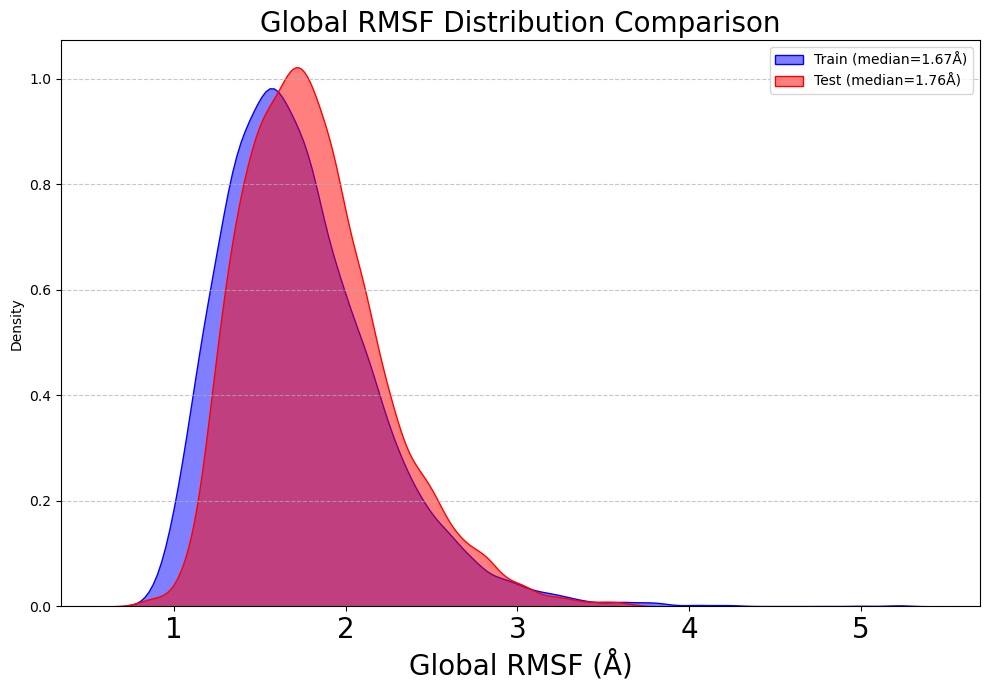

In [18]:
import pandas as pd
import os 
#
pdb_list1 = []
dcd_list1 = []
pdb_list2 = []
dcd_list2 = []
#
pdbxtc = '/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/pdbxtc/chain-r1'
train_csv = '/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/main-csv/train.csv'
test_csv = '/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/main-csv/test.csv'
out_png ='/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/analysis/rmsf/train-test.png'
#
df_train = pd.read_csv(train_csv)
df_test = pd.read_csv(test_csv)

for protein,fragment in zip(df_train['proteins'],df_train['fragments']):
    for chain in ['A', 'B', 'C']:
        pdb = os.path.join(pdbxtc,f'{protein}-{fragment}-{chain}.pdb')
        dcd = os.path.join(pdbxtc,f'{protein}-{fragment}-{chain}.xtc')
        pdb_list1.append(pdb)
        dcd_list1.append(dcd)
for protein,fragment in zip(df_test['proteins'],df_test['fragments']):
    for chain in ['A', 'B', 'C']:
        pdb = os.path.join(pdbxtc,f'{protein}-{fragment}-{chain}.pdb')
        dcd = os.path.join(pdbxtc,f'{protein}-{fragment}-{chain}.xtc')
        pdb_list2.append(pdb)
        dcd_list2.append(dcd)
plot_rmsf_comparison(pdb_list1, dcd_list1, pdb_list2, dcd_list2,out_png, stride=40, label1='Train', label2='Test')

# Experiment

## Train

### finetune
#### mdgen
##### wt
cd /mnt/hdd/jeff/MDGen/model/0-scratch/scratch-if-chain
python train.py \
  --finetune \
  --ckpt /mnt/hdd/jeff/MDGen/data/experiment/finetune/mdgen/train_atlas-test_wt/ckpt/atlas.ckpt \
  --sim_condition \
  --train_split /home/r12521230/hdd/jeff/mdgen-collagen/data/wt-collagen/main-csv/train.csv \
  --val_split /home/r12521230/hdd/jeff/mdgen-collagen/data/wt-collagen/main-csv/val.csv \
  --data_dir /home/r12521230/hdd/jeff/mdgen-collagen/data/wt-collagen/npy \
  --csv_dir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/csv-new \
  --num_frames 250 \
  --unfreeze_start_layer 0 \
  --batch_size 1 \
  --prepend_ipa \
  --crop 85 \
  --atlas \
  --ckpt_freq 10 \
  --run_name 0402-finetune-mdgen-collagen \
  --val_repeat 25 \
  --epochs 100 \
  --warmup_steps 150 \
  --grad_checkpointing \
  --lr 5e-5

### scratch
#### mdgen
cd /home/r12521230/hdd/jeff/mdgen-collagen/model/wt-collagen
python train.py \
  --sim_condition \
  --train_split /home/r12521230/hdd/jeff/mdgen-collagen/data/wt-collagen/main-csv/train.csv \
  --val_split /home/r12521230/hdd/jeff/mdgen-collagen/data/wt-collagen/main-csv/val.csv \
  --data_dir /home/r12521230/hdd/jeff/mdgen-collagen/data/wt-collagen/npy \
  --num_frames 250 \
  --batch_size 1 \
  --prepend_ipa \
  --crop 85 \
  --atlas \
  --ckpt_freq 10 \
  --run_name 0318-mdgen-col \
  --val_repeat 25 \
  --epochs 1000 \
  --warmup_steps 0 \
  --grad_checkpointing

#### mdgen_chain
cd /home/r12521230/hdd/jeff/mdgen-collagen/model/wt-collagen
python train.py \
  --sim_condition \
  --use_chain_emb \
  --train_split /home/r12521230/hdd/jeff/mdgen-collagen/data/wt-collagen/main-csv/train.csv \
  --val_split /home/r12521230/hdd/jeff/mdgen-collagen/data/wt-collagen/main-csv/val.csv \
  --data_dir /home/r12521230/hdd/jeff/mdgen-collagen/data/wt-collagen/npy \
  --num_frames 250 \
  --batch_size 1 \
  --prepend_ipa \
  --crop 85 \
  --atlas \
  --ckpt_freq 10 \
  --run_name 0318-chain-col \
  --val_repeat 25 \
  --epochs 1000 \
  --warmup_steps 0 \
  --grad_checkpointing

## check use_chain_emb

In [ ]:
import torch

def check_chain_emb(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)

    # ---------- use_chain_emb ----------
    use_chain = None
    if "hyper_parameters" in ckpt and "args" in ckpt["hyper_parameters"]:
        args = ckpt["hyper_parameters"]["args"]
        args_dict = vars(args) if hasattr(args, "__dict__") else args
        use_chain = args_dict.get("use_chain_emb", None)

    # ---------- chain_embedding weight ----------
    sd = ckpt.get("state_dict", ckpt)
    has_chain_weight = any("chain_embedding" in k for k in sd.keys())

    print("use_chain_emb:", use_chain)
    print("has_chain_embedding_weight:", has_chain_weight)

check_chain_emb('/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/ckpt/mdgen/epoch=999-step=80000.ckpt')

## Inference-scratch

cd /mnt/hdd/jeff/MDGen/model/0-scratch/scratch-if-chain
### github
#### single chain
python sim_inference-collagen-single.py \
--sim_ckpt /mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt1/ckpt/atlas.ckpt \
--data_dir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/npy/chain-r1 \
--num_frames 250 \
--num_rollouts 1 \
--split /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/main-csv/test.csv \
--csv_dir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/csv-new \
--out_dir /mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt1/inference \
--xtc
#### three chain
python sim_inference-collagen.py \
--sim_ckpt /mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt3/ckpt/atlas.ckpt \
--data_dir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/npy/chain-r1 \
--num_frames 250 \
--num_rollouts 1 \
--split /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/main-csv/test.csv \
--csv_dir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/csv-new \
--out_dir /mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt3/inference \
--xtc

### mdgen_chain
#### train_wt-test_wt-mdgen_chain
python sim_inference-collagen.py \
--sim_ckpt /mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_wt-test_wt/ckpt/epoch=999-step=80000.ckpt \
--data_dir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/npy/chain-r1 \
--num_frames 250 \
--num_rollouts 1 \
--split /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/main-csv/test.csv \
--csv_dir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/csv-new \
--out_dir /mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_wt-test_wt/inference \
--xtc

#### train_satlas-test_satlas-mdgen_chain
python sim_inference-atlas.py \
--sim_ckpt /mnt/hdd/jeff/MDGen/data/dataset/mdgen-atlas/ckpt/chain/epoch=999-step=85000.ckpt \
--data_dir /mnt/hdd/jeff/MDGen/data/dataset/mdgen-atlas/raw/npy \
--num_frames 250 \
--num_rollouts 1 \
--suffix _R1 \
--split /mnt/hdd/jeff/MDGen/data/dataset/mdgen-atlas/small/main-csv/test.csv \
--out_dir /mnt/hdd/jeff/MDGen/data/experiment/scratch/small-atlas/chain/inference \
--xtc

#### train_satlas-test_wt-mdgen_chain
python sim_inference-collagen.py \
--sim_ckpt /mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_wt/ckpt/epoch=999-step=85000.ckpt \
--data_dir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/npy/chain-r1 \
--num_frames 250 \
--num_rollouts 1 \
--split /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/main-csv/test.csv \
--csv_dir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/csv-new \
--out_dir /mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_wt/inference \
--xtc

### mdgen
#### train_wt-test_wt-mdgen
python sim_inference-collagen.py \
--sim_ckpt /mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_wt-test_wt/ckpt/epoch=999-step=80000.ckpt \
--data_dir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/npy/chain-r1 \
--num_frames 250 \
--num_rollouts 1 \
--split /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/main-csv/test.csv \
--csv_dir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/csv-new \
--out_dir /mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_wt-test_wt/inference \
--xtc

#### train_satlas-test_satlas-mdgen
python sim_inference-atlas.py \
--sim_ckpt /mnt/hdd/jeff/MDGen/data/dataset/mdgen-atlas/ckpt/mdgen/epoch=999-step=85000.ckpt \
--data_dir /mnt/hdd/jeff/MDGen/data/dataset/mdgen-atlas/raw/npy \
--num_frames 250 \
--num_rollouts 1 \
--suffix _R1 \
--split /mnt/hdd/jeff/MDGen/data/dataset/mdgen-atlas/small/main-csv/test.csv \
--out_dir /mnt/hdd/jeff/MDGen/data/experiment/scratch/small-atlas/mdgen/inference \
--xtc

#### train_satlas-test_wt-mdgen
python sim_inference-collagen.py \
--sim_ckpt /mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_wt/ckpt/epoch=999-step=85000.ckpt \
--data_dir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/npy/chain-r1 \
--num_frames 250 \
--num_rollouts 1 \
--split /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/main-csv/test.csv \
--csv_dir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/csv-new \
--out_dir /mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_wt/inference \
--xtc

### mdgen-nipa
#### train_wt-test_wt-mdgen-nipa
python sim_inference-collagen.py \
--sim_ckpt /mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen-nipa/train_wt-test_wt/ckpt/epoch=999-step=80000.ckpt \
--data_dir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/npy/chain-r1 \
--num_frames 250 \
--num_rollouts 1 \
--split /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/main-csv/test.csv \
--csv_dir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/csv-new \
--out_dir /mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen-nipa/train_wt-test_wt/inference \
--xtc

### mdgen_chain-nipa
#### train_wt-test_wt-mdgen_chain-nipa
python sim_inference-collagen.py \
--sim_ckpt /mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain-nipa/train_wt-test_wt/ckpt/epoch=999-step=80000.ckpt \
--data_dir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/npy/chain-r1 \
--num_frames 250 \
--num_rollouts 1 \
--split /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/main-csv/test.csv \
--csv_dir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/csv-new \
--out_dir /mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain-nipa/train_wt-test_wt/inference \
--xtc

## inference-finetune

### train_atlas-test_wt-mdgen
python sim_inference-collagen.py \
--sim_ckpt /mnt/hdd/jeff/MDGen/data/experiment/finetune/mdgen/train_atlas-test_wt/ckpt/epoch=99-step=8000.ckpt \
--data_dir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/npy/chain-r1 \
--num_frames 250 \
--num_rollouts 1 \
--split /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/main-csv/test.csv \
--csv_dir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/csv-new \
--out_dir /mnt/hdd/jeff/MDGen/data/experiment/finetune/mdgen/train_atlas-test_wt/inference \
--xtc


## inference-train

### mdgen_chain-train_wt-test_wt
python sim_inference-collagen.py \
--sim_ckpt /mnt/hdd/jeff/MDGen/data/experiment/0408/training/mdgen_chain-train_wt-test_wt/ckpt/epoch=999-step=80000.ckpt \
--data_dir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/npy/chain-r1 \
--num_frames 250 \
--num_rollouts 1 \
--split /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/main-csv/train-test.csv \
--csv_dir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/csv-new \
--out_dir /mnt/hdd/jeff/MDGen/data/experiment/0408/training/mdgen_chain-train_wt-test_wt/inference \
--xtc

## pkl

### github
#### train_atlas-test_wt1
python -m scripts.analyze_ensembles-collagen \
--atlas_dir /mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/pdbxtc \
--pdbdir /mnt/hdd/jeff/MDGen/data/experiment/0408/training/mdgen_chain-train_wt-test_wt/inference \
--num_workers 4
#### train_satlas-test_satlas
python -m scripts.analyze_ensembles \
--atlas_dir /mnt/hdd/jeff/MDGen/data/dataset/mdgen-atlas/raw/protein \
--pdbdir /mnt/hdd/jeff/MDGen/data/experiment/scratch/small-atlas/mdgen/inference \
--num_workers 4

## 移除沒算成功的

In [1]:
import pickle

inp = "/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt3/pkl/out.pkl"
outp = "/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt3/pkl/clean.pkl"

with open(inp, "rb") as f:
    data = pickle.load(f)

clean = {k: v for k, v in data.items() if isinstance(v, dict) and ("error" not in v)}

print("before:", len(data), "after:", len(clean))

with open(outp, "wb") as f:
    pickle.dump(clean, f)


before: 117 after: 117


## print table
cd /mnt/hdd/jeff/MDGen/model/0-scratch/mdgen-#1
python -m scripts.print_analysis /mnt/hdd/jeff/MDGen/data/experiment/0408/training/mdgen_chain-train_wt-test_wt/pkl/out.pkl

# Analysis

### training loss

In [71]:
import re
import ast
import matplotlib.pyplot as plt


def plot_train_val_loss_last_run(log_path, out_png, title, max_epoch=1000):
    train_records = []
    val_records = []

    with open(log_path, 'r', encoding='utf-8') as f:
        for line in f:
            if '[INFO]' not in line or '{' not in line:
                continue

            m = re.search(r'(\{.*\})', line)
            if not m:
                continue

            raw = m.group(1).replace('nan', 'None')

            try:
                d = ast.literal_eval(raw)
            except Exception:
                continue

            if 'epoch' not in d or d['epoch'] is None:
                continue

            epoch = d['epoch']
            trainer_step = d.get('trainer_step', None)

            if 'train_loss' in d and d['train_loss'] is not None:
                train_records.append({
                    'epoch': epoch,
                    'trainer_step': trainer_step,
                    'loss': d['train_loss']
                })

            if 'val_loss' in d and d['val_loss'] is not None:
                val_records.append({
                    'epoch': epoch,
                    'trainer_step': trainer_step,
                    'loss': d['val_loss']
                })

    if len(train_records) == 0 and len(val_records) == 0:
        raise ValueError('沒有從 log 中找到 train_loss 或 val_loss')

    # -------------------------
    # 找最後一次訓練開始的位置
    # epoch 如果從大跳回小，表示開始新的 training run
    # -------------------------
    all_epochs = []
    for r in train_records:
        all_epochs.append(r['epoch'])
    for r in val_records:
        all_epochs.append(r['epoch'])

    # 只靠合併後的 epoch 不夠穩，所以直接重新掃 log 會更準
    all_records = []

    with open(log_path, 'r', encoding='utf-8') as f:
        for line in f:
            if '[INFO]' not in line or '{' not in line:
                continue

            m = re.search(r'(\{.*\})', line)
            if not m:
                continue

            raw = m.group(1).replace('nan', 'None')

            try:
                d = ast.literal_eval(raw)
            except Exception:
                continue

            if 'epoch' not in d or d['epoch'] is None:
                continue

            rec_type = None
            loss = None
            if 'train_loss' in d and d['train_loss'] is not None:
                rec_type = 'train'
                loss = d['train_loss']
            elif 'val_loss' in d and d['val_loss'] is not None:
                rec_type = 'val'
                loss = d['val_loss']
            else:
                continue

            all_records.append({
                'type': rec_type,
                'epoch': d['epoch'],
                'trainer_step': d.get('trainer_step', None),
                'loss': loss
            })

    if len(all_records) == 0:
        raise ValueError('沒有有效的 train/val loss 紀錄')

    # 找最後一次 epoch reset 的位置
    last_reset_idx = 0
    prev_epoch = all_records[0]['epoch']
    for i in range(1, len(all_records)):
        curr_epoch = all_records[i]['epoch']
        if curr_epoch < prev_epoch:
            last_reset_idx = i
        prev_epoch = curr_epoch

    # 只保留最後一次訓練
    all_records = all_records[last_reset_idx:]

    # 只保留最後 max_epoch 個 epoch
    all_records = [r for r in all_records if r['epoch'] < max_epoch]

    train_x, train_y = [], []
    val_x, val_y = [], []

    for r in all_records:
        if r['type'] == 'train':
            train_x.append(r['epoch'])
            train_y.append(r['loss'])
        elif r['type'] == 'val':
            val_x.append(r['epoch'])
            val_y.append(r['loss'])

    if len(train_y) == 0 and len(val_y) == 0:
        raise ValueError('最後一次訓練中沒有找到 train_loss 或 val_loss')

    plt.figure(figsize=(8, 5))

    if len(train_y) > 0:
        plt.plot(train_x, train_y, marker='o', markersize=4, label='train_loss')

    if len(val_y) > 0:
        plt.plot(val_x, val_y, marker='s', markersize=4, label='val_loss')

    plt.xlabel('Epoch', fontsize=18)
    plt.ylabel('Loss', fontsize=18)
    plt.ylim(0,2.5)
    plt.title(title, fontsize=18)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.show()

    print(f'Saved to: {out_png}')
    print(f'last reset index: {last_reset_idx}')
    print(f'train points: {len(train_y)}')
    print(f'val points: {len(val_y)}')
    print(f'epoch range: 0 ~ {max(train_x + val_x) if (train_x or val_x) else "N/A"}')

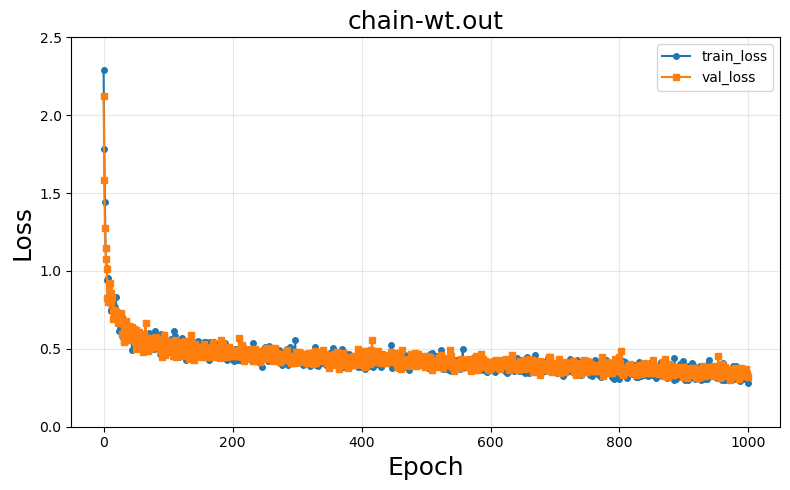

Saved to: /mnt/hdd/jeff/MDGen/data/experiment/training/analysis/chain-wt_loss.png
last reset index: 0
train points: 1000
val points: 1000
epoch range: 0 ~ 999


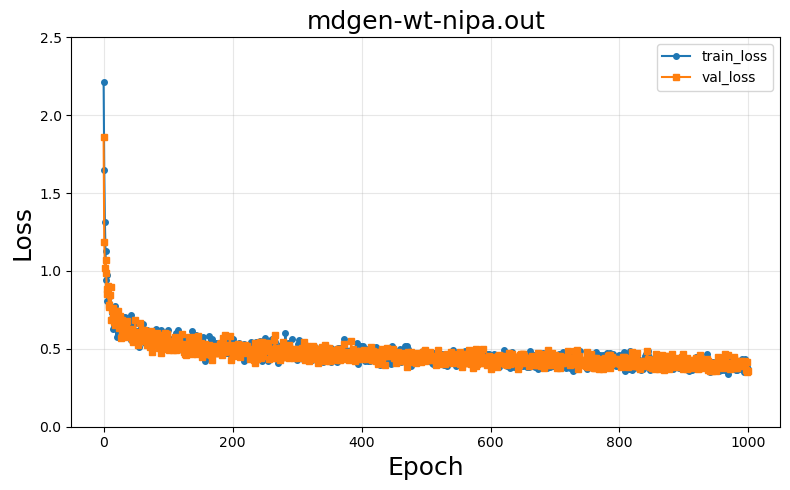

Saved to: /mnt/hdd/jeff/MDGen/data/experiment/training/analysis/mdgen-wt-nipa_loss.png
last reset index: 0
train points: 1000
val points: 1000
epoch range: 0 ~ 999


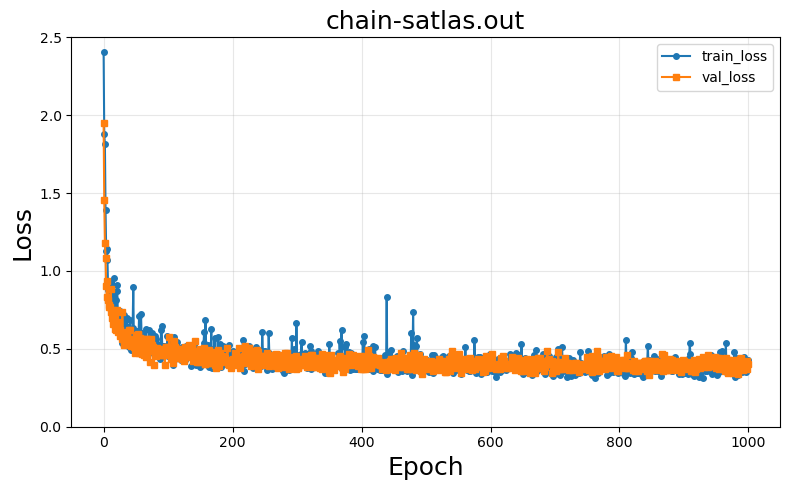

Saved to: /mnt/hdd/jeff/MDGen/data/experiment/training/analysis/chain-satlas_loss.png
last reset index: 562
train points: 1000
val points: 1000
epoch range: 0 ~ 999


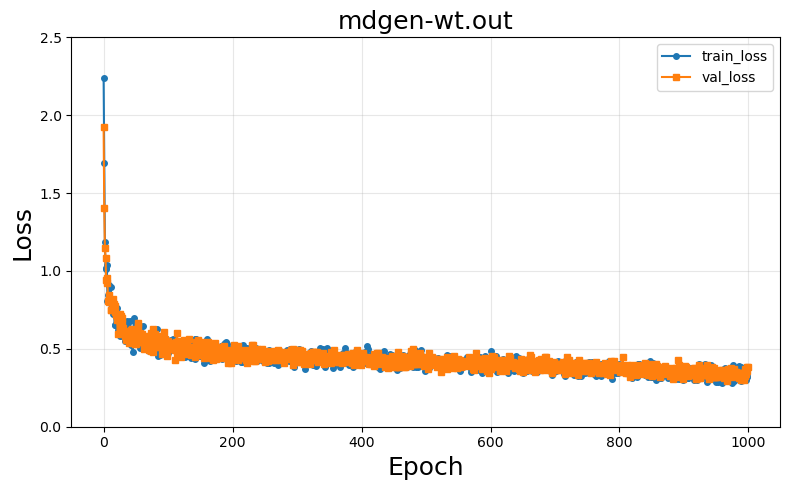

Saved to: /mnt/hdd/jeff/MDGen/data/experiment/training/analysis/mdgen-wt_loss.png
last reset index: 0
train points: 1000
val points: 1000
epoch range: 0 ~ 999


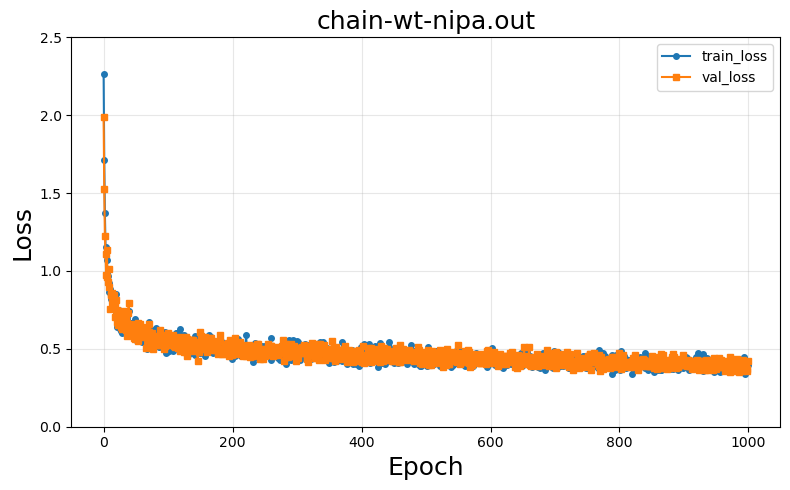

Saved to: /mnt/hdd/jeff/MDGen/data/experiment/training/analysis/chain-wt-nipa_loss.png
last reset index: 0
train points: 1000
val points: 1000
epoch range: 0 ~ 999


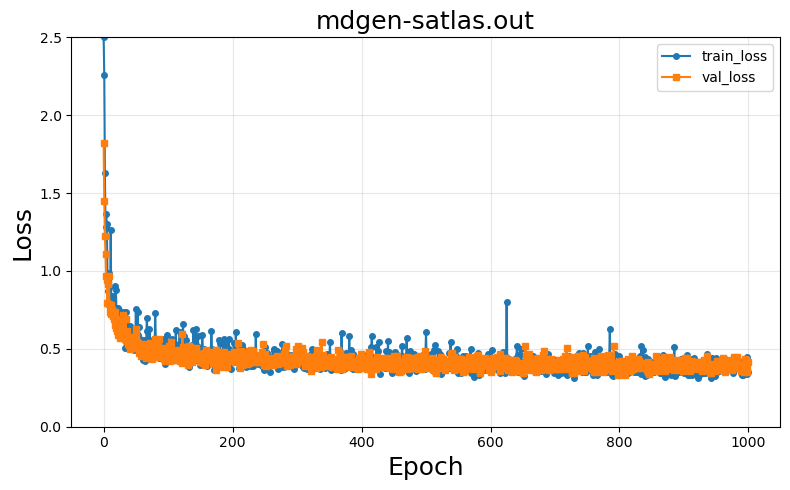

Saved to: /mnt/hdd/jeff/MDGen/data/experiment/training/analysis/mdgen-satlas_loss.png
last reset index: 562
train points: 1000
val points: 1000
epoch range: 0 ~ 999


In [72]:
import os
log_path = '/mnt/hdd/jeff/MDGen/data/experiment/training/log'
analysis_path = '/mnt/hdd/jeff/MDGen/data/experiment/training/analysis'
for log_file in os.listdir(log_path):
    title = log_file
    log_full_path = os.path.join(log_path, log_file)
    out_png = os.path.join(analysis_path, f'{os.path.splitext(log_file)[0]}_loss.png')
    plot_train_val_loss_last_run(log_full_path, out_png,title)

### protein name pkl

In [6]:
with open('/mnt/hdd/jeff/MDGen/data/experiment/paper/wt-collagen/pkl/clean.pkl', 'rb') as f:
    data = pickle.load(f)

print(type(data))
print(list(data.keys())[:10])

<class 'dict'>
['wt-75-A', 'wt-88-C', 'wt-76-B', 'wt-96-B', 'wt-62-B', 'wt-90-B', 'wt-95-C', 'wt-72-C', 'wt-87-B', 'wt-79-C']


### pca

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def pca_joint_align_from_npy85(
    npy_1,
    npy_2,
    out_png,
    label=("npy_1", "npy_2"),
    marker=("o", "o"),
    n_frames_1=250,          # npy_1 等距抽樣數
    stride_2=1,              # npy_2 可選抽樣
    ca_idx=1,                # atom14 的 CA index
    random_state=0,
    cmap_list=("red", "blue"),
    point_size=10,
    alpha=0.85,
    annotate_every=1000,
):
    """
    npy_1: atom14 (T1, 85, 14, 3) 例如 (3000,85,14,3)；會等距取 n_frames_1
    npy_2: atom14 (T2, 85, 14, 3)；完整使用（可用 stride_2 抽樣）
    """

    from sklearn.decomposition import PCA

    # ---------- Kabsch ----------
    def _kabsch(P, Q):
        C = P.T @ Q
        V, S, Wt = np.linalg.svd(C)
        d = np.sign(np.linalg.det(V @ Wt))
        D = np.diag([1.0, 1.0, d])
        return V @ D @ Wt

    def _align_to_ref_ca(X, Xref):
        """
        用 CA 做對齊，旋轉套用到整個 atom14。
        X, Xref: (85,14,3)
        """
        ca = X[:, ca_idx, :]       # (85,3)
        ca_ref = Xref[:, ca_idx, :]

        mask = (np.abs(ca).sum(axis=1) > 0) & (np.abs(ca_ref).sum(axis=1) > 0)
        if mask.sum() < 3:
            return X

        P = ca[mask]
        Q = ca_ref[mask]

        Pc = P - P.mean(axis=0, keepdims=True)
        Qc = Q - Q.mean(axis=0, keepdims=True)

        R = _kabsch(Pc, Qc)

        center = P.mean(axis=0, keepdims=True)   # (1,3)
        target = Q.mean(axis=0, keepdims=True)   # (1,3)

        Xc = X - center.reshape(1, 1, 3)
        X_aligned = Xc @ R + target.reshape(1, 1, 3)
        return X_aligned

    # ---------- load ----------
    A = np.load(npy_1) if isinstance(npy_1, str) else np.asarray(npy_1)
    B = np.load(npy_2) if isinstance(npy_2, str) else np.asarray(npy_2)

    if A.ndim != 4 or A.shape[1:] != (85, 14, 3):
        raise ValueError(f"npy_1 shape 不對，期望 (T,85,14,3)，但得到 {A.shape}")
    if B.ndim != 4 or B.shape[1:] != (85, 14, 3):
        raise ValueError(f"npy_2 shape 不對，期望 (T,85,14,3)，但得到 {B.shape}")

    # ---------- npy_1：等距取 n_frames_1 ----------
    T1 = A.shape[0]
    if T1 < n_frames_1:
        raise ValueError(f"npy_1 frames={T1} < n_frames_1={n_frames_1}")

    idx1 = np.linspace(0, T1 - 1, n_frames_1).round().astype(int)
    A_use = A[idx1]

    # ---------- npy_2：可抽樣 ----------
    B_use = B[::max(int(stride_2), 1)]

    # ---------- global ref ----------
    global_ref = A_use[0].copy()

    # ---------- collect aligned ----------
    all_flat = []
    traj_id = []

    for t in range(A_use.shape[0]):
        X_aligned = _align_to_ref_ca(A_use[t], global_ref)
        all_flat.append(X_aligned.reshape(-1))
        traj_id.append(0)

    for t in range(B_use.shape[0]):
        X_aligned = _align_to_ref_ca(B_use[t], global_ref)
        all_flat.append(X_aligned.reshape(-1))
        traj_id.append(1)

    Xall = np.asarray(all_flat, dtype=np.float64)
    traj_id = np.array(traj_id, dtype=int)

    # ---------- PCA ----------
    pca = PCA(n_components=2, random_state=random_state)
    Y = pca.fit_transform(Xall)

    # ---------- plot ----------
    plt.figure(figsize=(7, 6), dpi=180)

    for tid in [0, 1]:
        m = (traj_id == tid)
        if not np.any(m):
            continue

        Y_tid = Y[m]
        n_frames = len(Y_tid)

        plt.scatter(
            Y_tid[:, 0],
            Y_tid[:, 1],
            s=point_size,
            alpha=alpha,
            marker=marker[tid],
            color=cmap_list[tid % len(cmap_list)],
            label=label[tid],
        )

        if annotate_every is not None and annotate_every > 0:
            step = int(annotate_every)
            for k in range(0, n_frames, step):
                plt.text(
                    Y_tid[k, 0],
                    Y_tid[k, 1],
                    str(k),
                    fontsize=point_size,
                    color="black",
                    alpha=0.9,
                )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png)
    plt.close()

In [ ]:
npy_2 = '/mnt/hdd/jeff/dataset/mdgen-collagen/mdgen-collagen/WT-dataset/analysis/atlas_ckpt/inference-npy/wt-139-A.npy'

npy_1 = '/mnt/hdd/jeff/dataset/mdgen-collagen/mdgen-collagen/WT-dataset/raw/npy/wt-139-A.npy'
label=['md-A','mdgen-A']
marker=['o','o','o','o','o','o','o','o']
out_png = '/mnt/hdd/jeff/dataset/mdgen-collagen/mdgen-collagen/WT-dataset/analysis/atlas_ckpt/pca/wt139A.png'
pca_joint_align_from_npy85(
    npy_1,
    npy_2,
    out_png,
    label=label,
    marker=marker)

### Global rmsf r

In [7]:
def plot_global_rmsf_scatter(
    pdb_list1, pdb_list2,
    dcd_list1, dcd_list2,
    out_png,name,
    start=0, end=None,
    stride1=1, stride2=1
):
    """
    x 軸 = traj1 的 residue RMSF
    y 軸 = traj2 的 residue RMSF
    """

    import numpy as np
    import matplotlib.pyplot as plt
    import MDAnalysis as mda

    if not (len(pdb_list1) == len(pdb_list2) == len(dcd_list1) == len(dcd_list2)):
        raise ValueError("pdb_list1, pdb_list2, dcd_list1, dcd_list2 長度必須一致")

    all_rmsf_1 = []
    all_rmsf_2 = []

    for i, (pdb1, pdb2, dcd1, dcd2) in enumerate(zip(pdb_list1, pdb_list2, dcd_list1, dcd_list2)):

        u1 = mda.Universe(pdb1, dcd1)
        u2 = mda.Universe(pdb2, dcd2)

        ca1 = u1.select_atoms("protein and name CA")
        ca2 = u2.select_atoms("protein and name CA")

        if len(ca1) == 0 or len(ca2) == 0:
            raise ValueError(f"第 {i+1} 組沒有選到 CA 原子")

        if len(ca1) != len(ca2):
            raise ValueError(f"第 {i+1} 組兩條 trajectory 的 CA 數量不同")

        # ===== traj1 =====
        pos1 = []
        for ts in u1.trajectory[start:end:stride1]:
            pos1.append(ca1.positions.copy())
        pos1 = np.asarray(pos1, dtype=np.float64)

        # ===== traj2 =====
        pos2 = []
        for ts in u2.trajectory[start:end:stride2]:
            pos2.append(ca2.positions.copy())
        pos2 = np.asarray(pos2, dtype=np.float64)

        if pos1.shape[0] < 2 or pos2.shape[0] < 2:
            raise ValueError(f"第 {i+1} 組可用 frame 太少")

        mean1 = pos1.mean(axis=0)
        mean2 = pos2.mean(axis=0)

        rmsf1 = np.sqrt(((pos1 - mean1[None, :, :]) ** 2).mean(axis=0).sum(axis=1))
        rmsf2 = np.sqrt(((pos2 - mean2[None, :, :]) ** 2).mean(axis=0).sum(axis=1))

        all_rmsf_1.append(rmsf1)
        all_rmsf_2.append(rmsf2)

    all_rmsf_1 = np.concatenate(all_rmsf_1)
    all_rmsf_2 = np.concatenate(all_rmsf_2)

    # Pearson r
    r = np.corrcoef(all_rmsf_1, all_rmsf_2)[0, 1] if len(all_rmsf_1) > 1 else np.nan

    # ===== plot =====
    plt.figure(figsize=(6, 6))

    # scatter
    plt.scatter(all_rmsf_1, all_rmsf_2, s=8, alpha=0.6)

    xy_min = min(all_rmsf_1.min(), all_rmsf_2.min())
    xy_max = max(all_rmsf_1.max(), all_rmsf_2.max())
    pad = 0.05 * (xy_max - xy_min + 1e-12)

    plt.plot(
        [xy_min - pad, xy_max + pad],
        [xy_min - pad, xy_max + pad],
        linestyle="--",
        linewidth=1.5
    )

    plt.xlim(xy_min - pad, xy_max + pad)
    plt.ylim(xy_min - pad, xy_max + pad)

    # labels
    plt.xlabel("MD RMSF (Å)", fontsize=20)
    plt.ylabel("MDGen RMSF (Å)", fontsize=20)

    # ticks
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # title
    plt.title(
        f"{name}\nPearson r = {r:.3f}, N = {len(all_rmsf_1)}",
        fontsize=20
    )

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved: {out_png}")
    print(f"Pearson r = {r:.6f}")

In [ ]:
name = '7c45_A'
pdb_list1 = [f'/mnt/hdd/jeff/MDGen/data/dataset/mdgen-atlas/raw/protein/{name}/{name}.pdb']
pdb_list2 = [f'/mnt/hdd/jeff/MDGen/data/experiment/train_atlas-test_atlas/mdgen_chain/inference/{name}_A.pdb']
dcd_list1 = [f'/mnt/hdd/jeff/MDGen/data/dataset/mdgen-atlas/raw/protein/{name}/{name}_prod_R1_fit.xtc']
dcd_list2 = [f'/mnt/hdd/jeff/MDGen/data/experiment/train_atlas-test_atlas/mdgen_chain/inference/{name}_A.xtc']
out_png = f'/mnt/hdd/jeff/MDGen/introductino/metric/global-rmsf-r/{name}.png'
plot_global_rmsf_scatter(pdb_list1, pdb_list2, dcd_list1, dcd_list2, out_png, name,stride1=40, stride2=1)

Saved: /mnt/hdd/jeff/MDGen/introductino/metric/global-rmsf-r/7c45_A.png
Pearson r = 0.169545


In [11]:
import os
mdgen_dir = '/mnt/hdd/jeff/MDGen/data/experiment/train_atlas-test_atlas/mdgen_chain/inference'
md_dir = '/mnt/hdd/jeff/MDGen/data/dataset/mdgen-atlas/raw/protein'
pdb_list1 = []
pdb_list2 = []
dcd_list1 = []
dcd_list2 = []
for protein in os.listdir(mdgen_dir):
    if not protein.endswith('.pdb'):
        continue

    name = protein[:-6]
    pdb_list1.append(f'{md_dir}/{name}/{name}.pdb')
    pdb_list2.append(f'{mdgen_dir}/{protein}')
    dcd_list1.append(f'{md_dir}/{name}/{name}_prod_R1_fit.xtc')
    dcd_list2.append(f'{mdgen_dir}/{protein[:-4]}.xtc')
out_png = f'/mnt/hdd/jeff/MDGen/introductino/metric/global-rmsf-r/full_small_atlas.png'
name= 'small_atlas'
plot_global_rmsf_scatter(pdb_list1, pdb_list2, dcd_list1, dcd_list2, out_png, name,stride1=40, stride2=1)


Saved: /mnt/hdd/jeff/MDGen/introductino/metric/global-rmsf-r/full_small_atlas.png
Pearson r = 0.524725


## pkl

In [1]:
def plot_rmsf_compare(
    pdb1, dcd1,
    pdb2, dcd2,
    out_png, name,
    start=0, end=None,
    stride1=1, stride2=1,
    label1="traj1",
    label2="traj2"
):
    """
    畫兩條 trajectory 的 residue RMSF 比較圖

    x 軸 = residue index
    y 軸 = RMSF (Å)
    """

    import numpy as np
    import matplotlib.pyplot as plt
    import MDAnalysis as mda

    # ===== read trajectories =====
    u1 = mda.Universe(pdb1, dcd1)
    u2 = mda.Universe(pdb2, dcd2)

    ca1 = u1.select_atoms("protein and name CA")
    ca2 = u2.select_atoms("protein and name CA")

    if len(ca1) == 0 or len(ca2) == 0:
        raise ValueError("沒有選到 CA 原子")

    if len(ca1) != len(ca2):
        raise ValueError("兩條 trajectory 的 CA 數量不同，無法直接比較")

    # ===== traj1 positions =====
    pos1 = []
    for ts in u1.trajectory[start::stride1]:
        pos1.append(ca1.positions.copy())
    pos1 = np.asarray(pos1, dtype=np.float64)

    # ===== traj2 positions =====
    pos2 = []
    for ts in u2.trajectory[start::stride2]:
        pos2.append(ca2.positions.copy())
    pos2 = np.asarray(pos2, dtype=np.float64)

    if pos1.shape[0] < 2 or pos2.shape[0] < 2:
        raise ValueError("可用 frame 太少，至少需要 2 個 frame")

    # ===== RMSF =====
    mean1 = pos1.mean(axis=0)
    mean2 = pos2.mean(axis=0)

    rmsf1 = np.sqrt(((pos1 - mean1[None, :, :]) ** 2).mean(axis=0).sum(axis=1))
    rmsf2 = np.sqrt(((pos2 - mean2[None, :, :]) ** 2).mean(axis=0).sum(axis=1))

    # residue index
    resids1 = ca1.resids
    resids2 = ca2.resids

    # 如果 resids 不同，至少先提醒
    if not np.array_equal(resids1, resids2):
        print("Warning: 兩條 trajectory 的 residue id 不完全一致，將使用第一條的 residue id 作圖")

    # Pearson correlation
    r = np.corrcoef(rmsf1, rmsf2)[0, 1] if len(rmsf1) > 1 else np.nan

    # ===== plot =====
    plt.figure(figsize=(8, 5))

    plt.plot(resids1, rmsf1, linewidth=2, label=label1)
    plt.plot(resids1, rmsf2, linewidth=2, label=label2)

    plt.xlabel("Residue", fontsize=16)
    plt.ylabel("RMSF (Å)", fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.title(f"{name}\nPearson r = {r:.3f}", fontsize=18)
    plt.legend(fontsize=12)

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved: {out_png}")
    print(f"Pearson r = {r:.6f}")

    return resids1, rmsf1, rmsf2

In [ ]:
name = '6d7y_B'
pdb1 = f'/mnt/hdd/jeff/MDGen/data/dataset/mdgen-atlas/raw/protein/{name}/{name}.pdb'
pdb2 = f'/mnt/hdd/jeff/MDGen/data/experiment/train_atlas-test_atlas/mdgen_chain/inference/{name}_A.pdb'
dcd1 = f'/mnt/hdd/jeff/MDGen/data/dataset/mdgen-atlas/raw/protein/{name}/{name}_prod_R1_fit.xtc'
dcd2 = f'/mnt/hdd/jeff/MDGen/data/experiment/train_atlas-test_atlas/mdgen_chain/inference/{name}_A.xtc'
out_png = f'/mnt/hdd/jeff/MDGen/introductino/metric/rmsf/{name}.png'

plot_rmsf_compare(
    pdb1, dcd1,
    pdb2, dcd2,
    out_png, name,
    stride1=40, stride2=1,
    label1="MD",
    label2="MDGen"
)

### pairwise rmsd

In [1]:
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats


def analyze_data(data):
    df = []
    for name, out in data.items():
        item = {
            'name': name,
            'md_pairwise': out['ref_mean_pairwise_rmsd'],
            'af_pairwise': out['af_mean_pairwise_rmsd'],
        }
        df.append(item)

    df = pd.DataFrame(df).set_index('name')
    return df


def plot_scatter_chain_colored(pkl_path, out_png,title,legend_bool=True):
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        df = analyze_data(data)

    # 🔥 把 chain 抽出來
    df['chain'] = df.index.str.split('-').str[-1]

    # 顏色設定（你也可以改）
    color_map = {
        'A': 'red',
        'B': 'blue',
        'C': 'green'
    }

    plt.figure(figsize=(6, 6))

    # 🔥 分組畫
    for chain, group in df.groupby('chain'):
        plt.scatter(
            group['md_pairwise'],
            group['af_pairwise'],
            label=f'Chain {chain}',
            alpha=0.7,
            color=color_map.get(chain, 'gray')
        )

    # 🔥 y=x 參考線
    min_val = min(df['md_pairwise'].min(), df['af_pairwise'].min())
    max_val = max(df['md_pairwise'].max(), df['af_pairwise'].max())
    plt.plot([min_val, max_val], [min_val, max_val], '--')

    # 🔥 correlation
    r, _ = scipy.stats.pearsonr(df['md_pairwise'], df['af_pairwise'])

    plt.xlabel('MD pairwise RMSD', fontsize=18)
    plt.ylabel('MDGen pairwise RMSD', fontsize=18)
    plt.title(f'{title}\nPearson r = {r:.3f}',fontsize=18)

    if legend_bool:
        plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.xlim(0,13)
    plt.ylim(0,13)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.savefig(out_png, dpi=300)
    plt.show()

    print(f'Pearson r = {r:.6f}')
    print(f'n = {len(df)}')

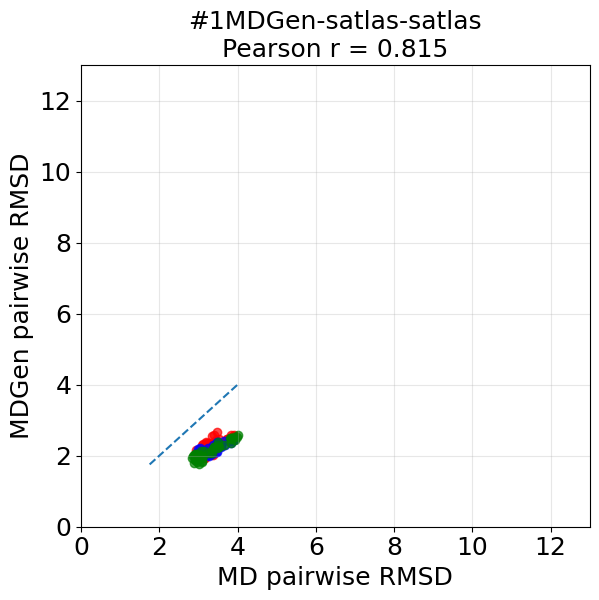

Pearson r = 0.815058
n = 120


In [2]:
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/0408/training/mdgen_chain-train_wt-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/0408/training/mdgen_chain-train_wt-test_wt/analysis/Maai-prmsd.png'
title='#1MDGen-satlas-satlas'
plot_scatter_chain_colored(pkl_path, out_png,title,legend_bool=False)

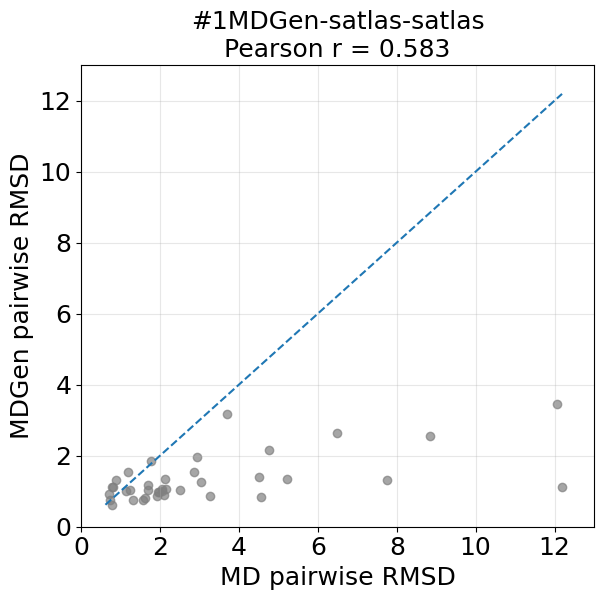

Pearson r = 0.583348
n = 38


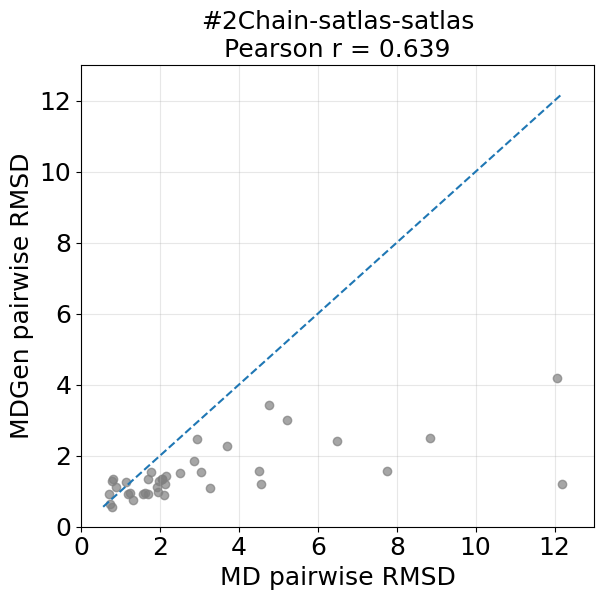

Pearson r = 0.639025
n = 38


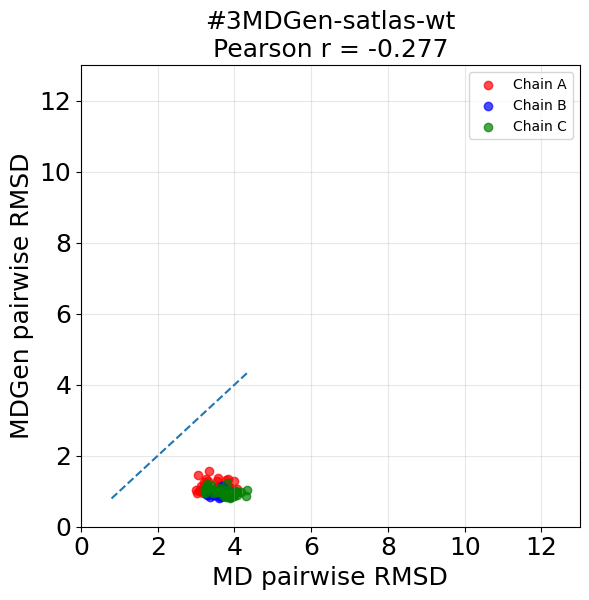

Pearson r = -0.277388
n = 117


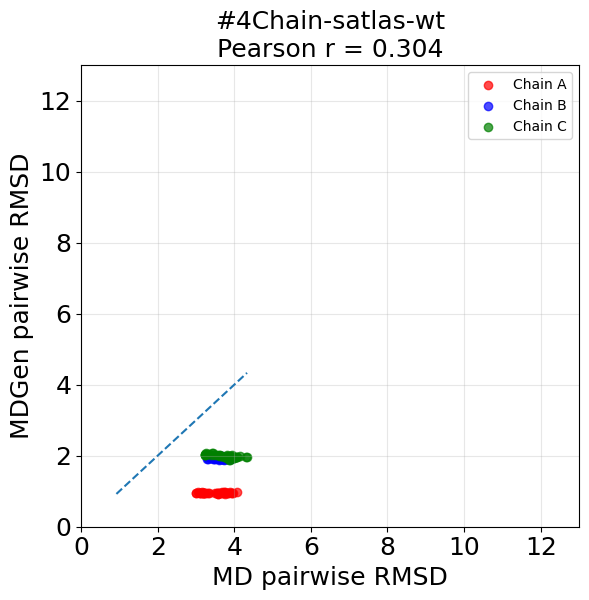

Pearson r = 0.304378
n = 117


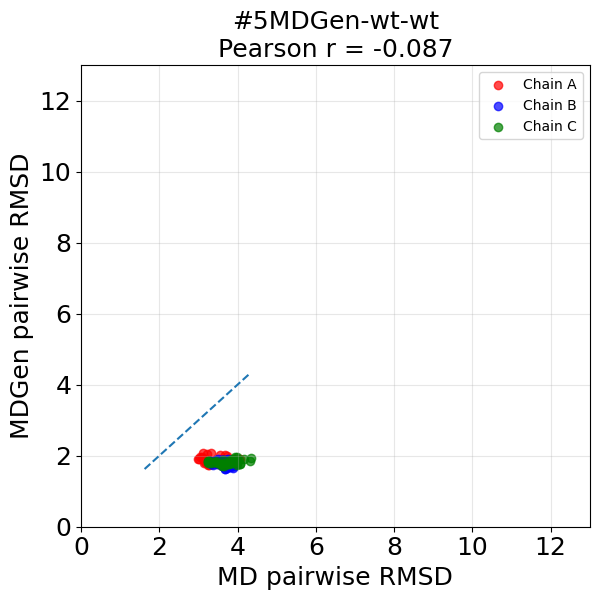

Pearson r = -0.087384
n = 117


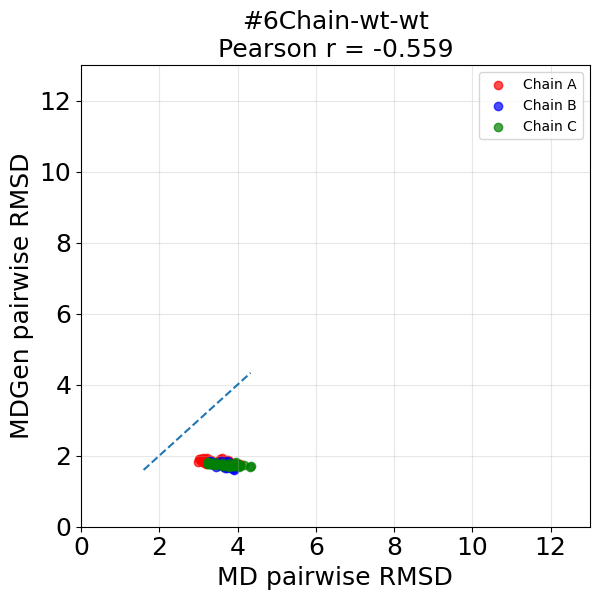

Pearson r = -0.559082
n = 117


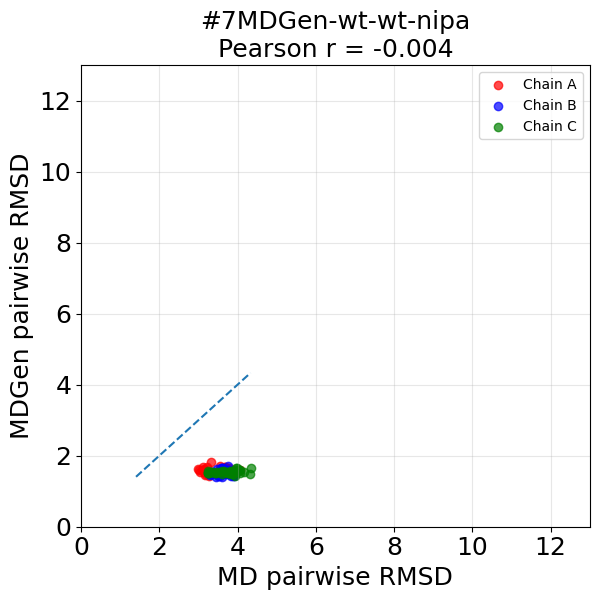

Pearson r = -0.004279
n = 117


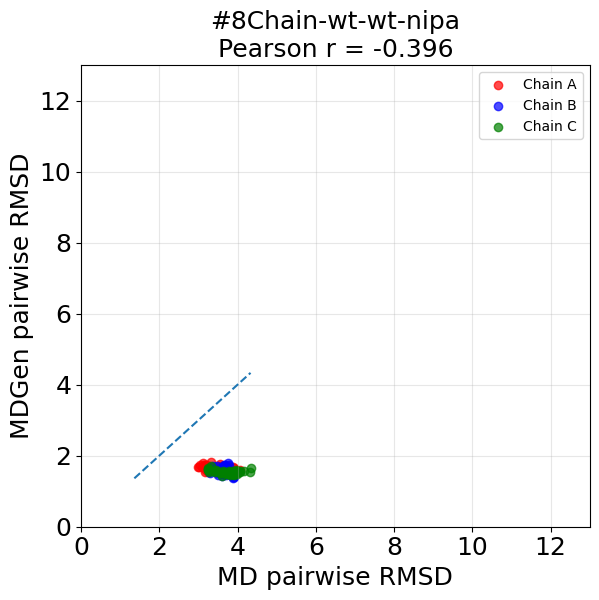

Pearson r = -0.395673
n = 117


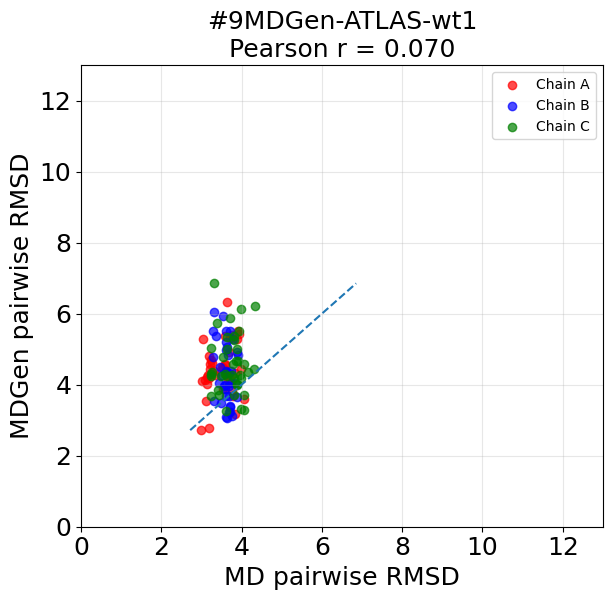

Pearson r = 0.069948
n = 117


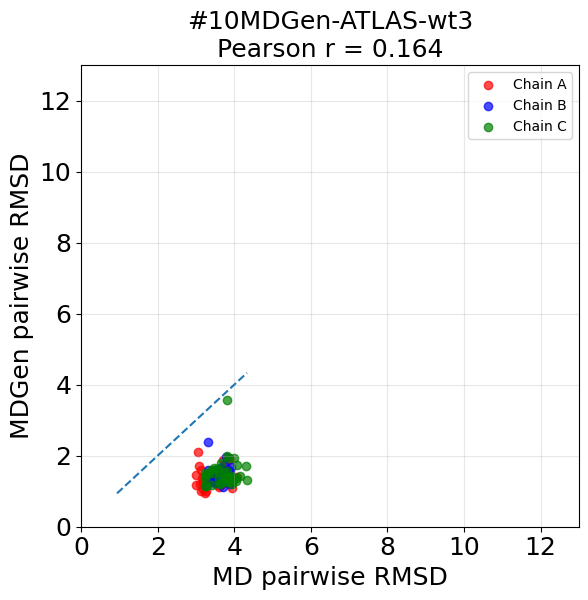

Pearson r = 0.163569
n = 117


In [57]:
#1 Maai
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_satlas/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_satlas/analysis/Maai-prmsd.png'
title='#1MDGen-satlas-satlas'
plot_scatter_chain_colored(pkl_path, out_png,title,legend_bool=False)

#2 Caai
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_satlas/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_satlas/analysis/Caai-prmsd.png'
title='#2Chain-satlas-satlas'
plot_scatter_chain_colored(pkl_path, out_png,title,legend_bool=False)

#3 Mawi
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_wt/analysis/Mawi-prmsd.png'
title='#3MDGen-satlas-wt'
plot_scatter_chain_colored(pkl_path, out_png,title)

#4 Cawi
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_wt/analysis/Cawi-prmsd.png'
title='#4Chain-satlas-wt'
plot_scatter_chain_colored(pkl_path, out_png,title)

#5 Mwwi
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_wt-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_wt-test_wt/analysis/Mwwi-prmsd.png'
title='#5MDGen-wt-wt'
plot_scatter_chain_colored(pkl_path, out_png,title)

#6 Cwwi
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_wt-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_wt-test_wt/analysis/Cwwi-prmsd.png'
title='#6Chain-wt-wt'
plot_scatter_chain_colored(pkl_path, out_png,title)

#7 Mwwn 
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen-nipa/train_wt-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen-nipa/train_wt-test_wt/analysis/Mwwn-prmsd.png'
title='#7MDGen-wt-wt-nipa'
plot_scatter_chain_colored(pkl_path, out_png,title)

#8 Cwwn
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain-nipa/train_wt-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain-nipa/train_wt-test_wt/analysis/Cwwn-prmsd.png'
title='#8Chain-wt-wt-nipa'
plot_scatter_chain_colored(pkl_path, out_png,title)

#9 MAwi1
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt1/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt1/analysis/MAwi1-prmsd.png'
title='#9MDGen-ATLAS-wt1'
plot_scatter_chain_colored(pkl_path, out_png,title)

#10 MAwi3
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt3/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt3/analysis/MAwi3-prmsd.png'
title='#10MDGen-ATLAS-wt3'
plot_scatter_chain_colored(pkl_path, out_png,title)

### global rmsf r

In [58]:
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats

def analyze_global_rmsf(data):
    """
    從 pkl 資料中提取每個原子的 MD 與 MDGen RMSF 數值，
    並根據 protein name (例如 protein-1-A) 標註所屬的 chain。
    """
    all_md_rmsf = []
    all_af_rmsf = []
    all_chains = []

    for name, out in data.items():
        # 跳過缺失資料的 case
        if 'ref_rmsf' not in out or 'af_rmsf' not in out:
            continue

        md_rmsf = np.asarray(out['ref_rmsf'])
        af_rmsf = np.asarray(out['af_rmsf'])

        # 長度檢查
        if len(md_rmsf) != len(af_rmsf):
            print(f'[skip] {name}: length mismatch')
            continue

        # 🔥 從 name 提取 chain ID (例如 "protein-1-A" -> "A")
        # 假設你的命名規則最後一節是 Chain ID
        chain_id = name.split('-')[-1]

        all_md_rmsf.append(md_rmsf)
        all_af_rmsf.append(af_rmsf)
        # 每個原子都要標註所屬的 chain
        all_chains.extend([chain_id] * len(md_rmsf))

    if len(all_md_rmsf) == 0:
        raise ValueError('No valid RMSF data found in pkl.')

    df = pd.DataFrame({
        'md_rmsf': np.concatenate(all_md_rmsf),
        'af_rmsf': np.concatenate(all_af_rmsf),
        'chain': all_chains
    })

    return df

def plot_global_rmsf_scatter_colored(pkl_path, out_png, title, legend_bool=True):
    """
    畫出 Global RMSF 散佈圖，並依據 Chain A/B/C 分顏色。
    """
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        df = analyze_global_rmsf(data)

    # 🔥 顏色設定：與你的 RMSD 畫法保持一致
    color_map = {
        'A': 'red',
        'B': 'blue',
        'C': 'green'
    }

    plt.figure(figsize=(6, 6))

    # 🔥 依據 chain 分組繪製散佈點
    for chain, group in df.groupby('chain'):
        plt.scatter(
            group['md_rmsf'],
            group['af_rmsf'],
            label=f'Chain {chain}',
            alpha=0.6,
            s=20,  # 點的大小
            color=color_map.get(chain, 'gray') # 若不在 ABC 內則顯示灰色
        )

    # 🔥 y=x 參考線
    all_min = min(df['md_rmsf'].min(), df['af_rmsf'].min())
    all_max = max(df['md_rmsf'].max(), df['af_rmsf'].max())
    plt.plot([all_min, all_max], [all_min, all_max], 'k--', alpha=0.5, label='y=x' if legend_bool else "")

    # 🔥 計算整體 Pearson correlation
    r, p = scipy.stats.pearsonr(df['md_rmsf'], df['af_rmsf'])

    # 樣式設定
    plt.xlabel('MD global RMSF', fontsize=18)
    plt.ylabel('MDGen global RMSF', fontsize=18)
    plt.title(f'{title}\nPearson r = {r:.3f}', fontsize=18)

    if legend_bool:
        plt.legend(fontsize=12)
        
    plt.grid(True, alpha=0.3)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    
    # 設定座標軸範圍（可根據你的數據分佈調整，例如 0 到 5）
    plt.xlim(0, 17)
    plt.ylim(0, 17)

    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.show()

    print(f'--- Global RMSF Analysis ---')
    print(f'Pearson r = {r:.6f}')
    print(f'p-value = {p:.6e}')
    print(f'Total atoms (n) = {len(df)}')
    print(f'Saved to: {out_png}')


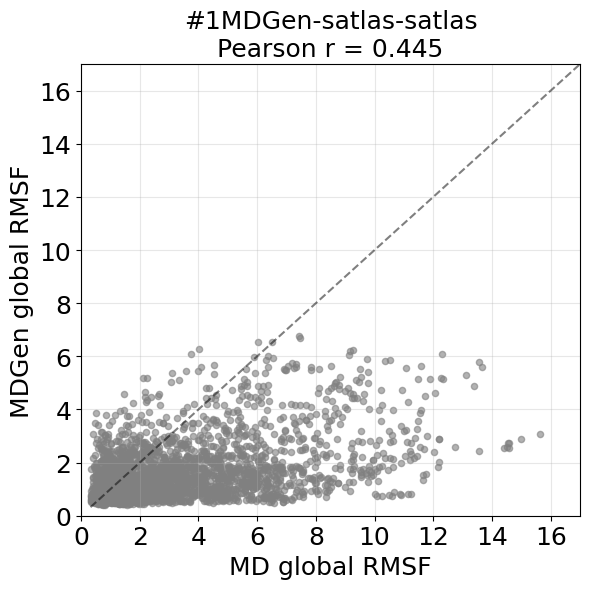

--- Global RMSF Analysis ---
Pearson r = 0.445460
p-value = 4.982661e-181
Total atoms (n) = 3724
Saved to: /mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_satlas/analysis/Maai-grmsf.png


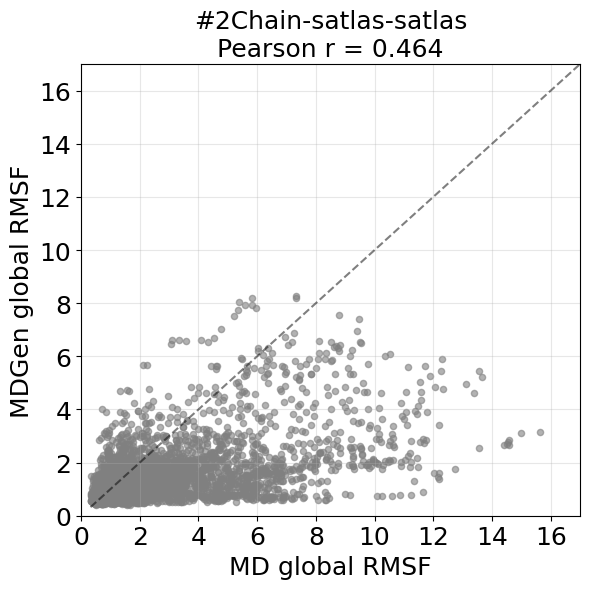

--- Global RMSF Analysis ---
Pearson r = 0.463842
p-value = 4.450465e-198
Total atoms (n) = 3724
Saved to: /mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_satlas/analysis/Caai-grmsf.png


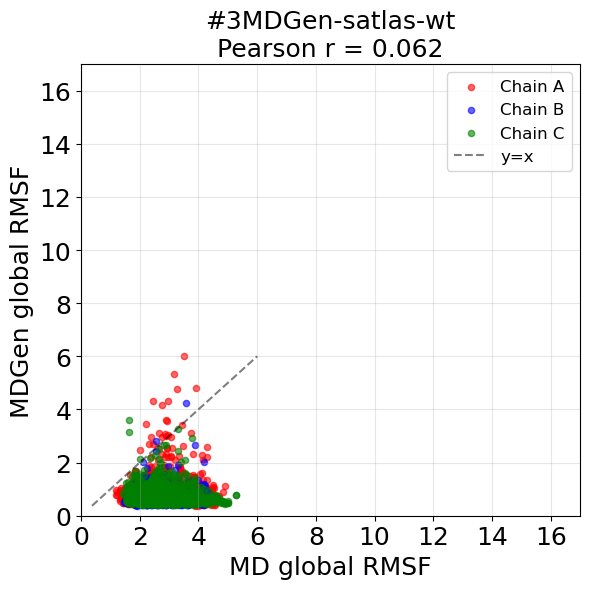

--- Global RMSF Analysis ---
Pearson r = 0.062313
p-value = 4.989474e-10
Total atoms (n) = 9945
Saved to: /mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_wt/analysis/Mawi-grmsf.png


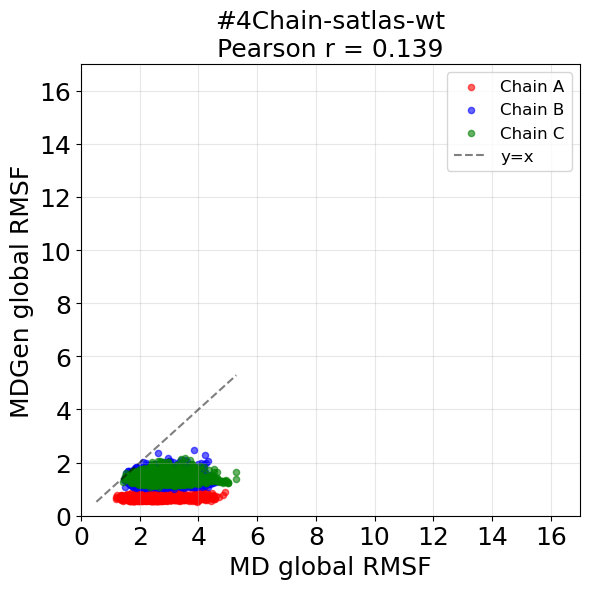

--- Global RMSF Analysis ---
Pearson r = 0.138644
p-value = 7.117456e-44
Total atoms (n) = 9945
Saved to: /mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_wt/analysis/Cawi-grmsf.png


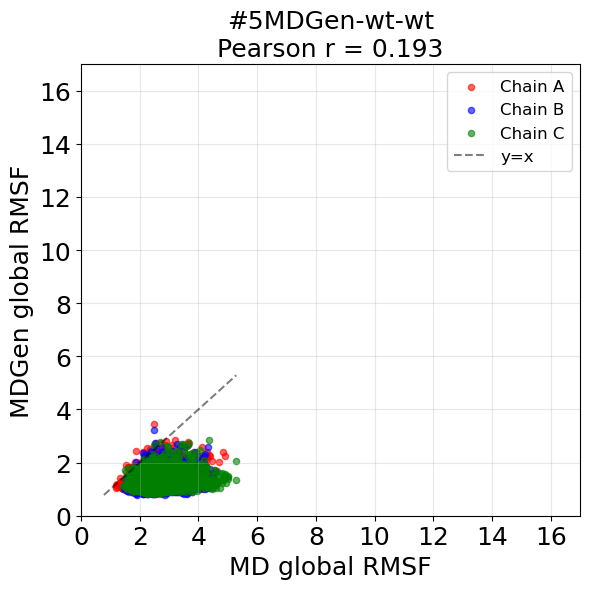

--- Global RMSF Analysis ---
Pearson r = 0.192743
p-value = 7.571352e-84
Total atoms (n) = 9945
Saved to: /mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_wt-test_wt/analysis/Mwwi-grmsf.png


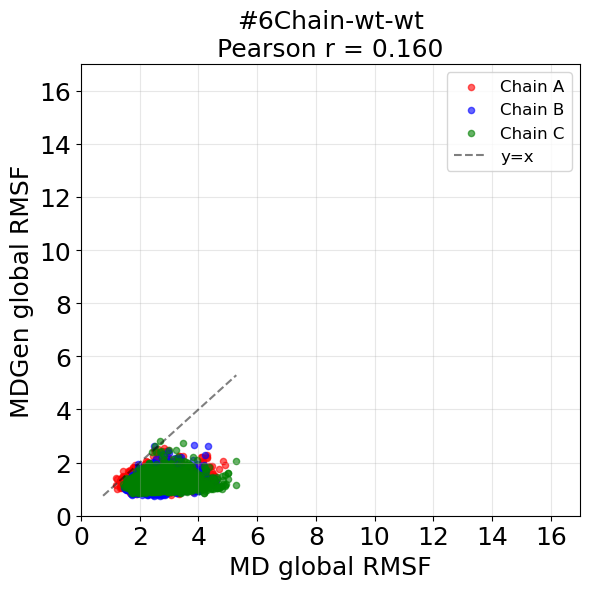

--- Global RMSF Analysis ---
Pearson r = 0.160193
p-value = 3.692635e-58
Total atoms (n) = 9945
Saved to: /mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_wt-test_wt/analysis/Cwwi-grmsf.png


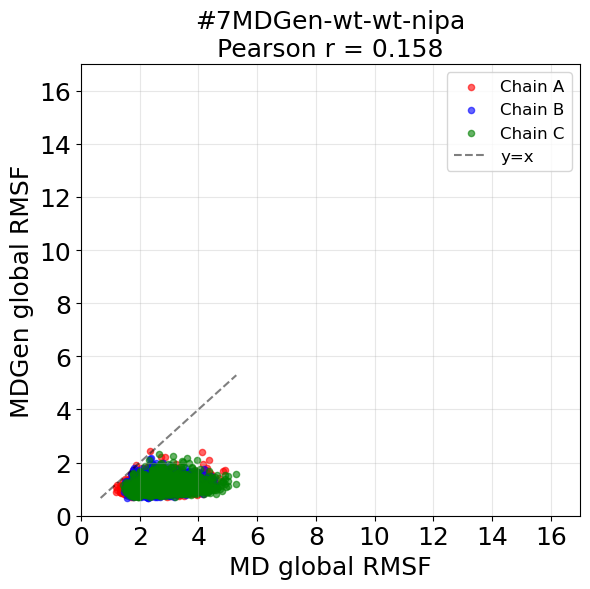

--- Global RMSF Analysis ---
Pearson r = 0.158302
p-value = 8.061513e-57
Total atoms (n) = 9945
Saved to: /mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen-nipa/train_wt-test_wt/analysis/Mwwn-grmsf.png


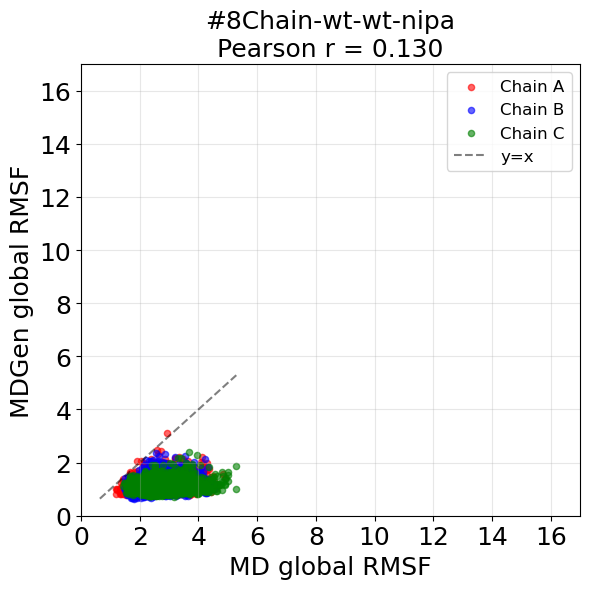

--- Global RMSF Analysis ---
Pearson r = 0.130273
p-value = 6.747648e-39
Total atoms (n) = 9945
Saved to: /mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain-nipa/train_wt-test_wt/analysis/Cwwn-grmsf.png


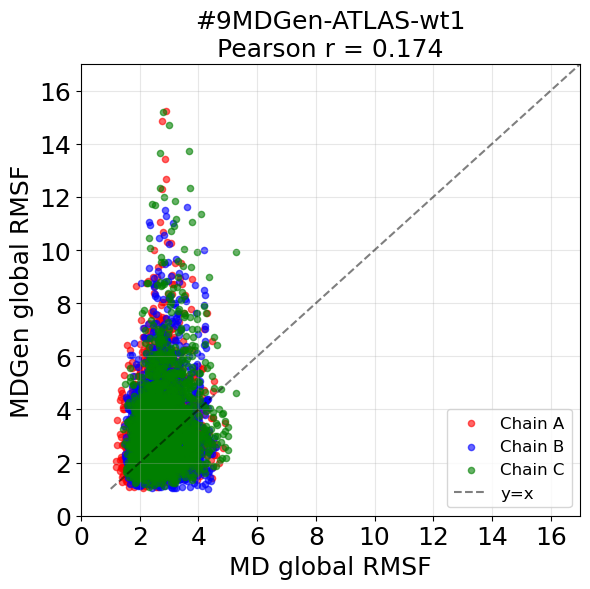

--- Global RMSF Analysis ---
Pearson r = 0.173826
p-value = 2.615128e-68
Total atoms (n) = 9945
Saved to: /mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt1/analysis/MAwi1-grmsf.png


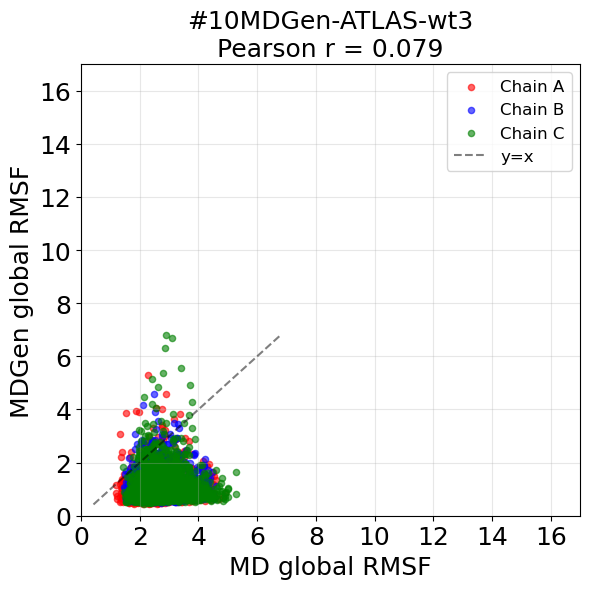

--- Global RMSF Analysis ---
Pearson r = 0.079198
p-value = 2.584843e-15
Total atoms (n) = 9945
Saved to: /mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt3/analysis/MAwi3-grmsf.png


In [59]:
#1 Maai
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_satlas/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_satlas/analysis/Maai-grmsf.png'
title='#1MDGen-satlas-satlas'
plot_global_rmsf_scatter_colored(pkl_path, out_png,title,legend_bool=False)

#2 Caai
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_satlas/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_satlas/analysis/Caai-grmsf.png'
title='#2Chain-satlas-satlas'
plot_global_rmsf_scatter_colored(pkl_path, out_png,title,legend_bool=False)

#3 Mawi
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_wt/analysis/Mawi-grmsf.png'
title='#3MDGen-satlas-wt'
plot_global_rmsf_scatter_colored(pkl_path, out_png,title)

#4 Cawi
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_wt/analysis/Cawi-grmsf.png'
title='#4Chain-satlas-wt'
plot_global_rmsf_scatter_colored(pkl_path, out_png,title)

#5 Mwwi
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_wt-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_wt-test_wt/analysis/Mwwi-grmsf.png'
title='#5MDGen-wt-wt'
plot_global_rmsf_scatter_colored(pkl_path, out_png,title)

#6 Cwwi
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_wt-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_wt-test_wt/analysis/Cwwi-grmsf.png'
title='#6Chain-wt-wt'
plot_global_rmsf_scatter_colored(pkl_path, out_png,title)

#7 Mwwn 
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen-nipa/train_wt-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen-nipa/train_wt-test_wt/analysis/Mwwn-grmsf.png'
title='#7MDGen-wt-wt-nipa'
plot_global_rmsf_scatter_colored(pkl_path, out_png,title)

#8 Cwwn
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain-nipa/train_wt-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain-nipa/train_wt-test_wt/analysis/Cwwn-grmsf.png'
title='#8Chain-wt-wt-nipa'
plot_global_rmsf_scatter_colored(pkl_path, out_png,title)

#9 MAwi1
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt1/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt1/analysis/MAwi1-grmsf.png'
title='#9MDGen-ATLAS-wt1'
plot_global_rmsf_scatter_colored(pkl_path, out_png,title)

#10 MAwi3
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt3/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt3/analysis/MAwi3-grmsf.png'
title='#10MDGen-ATLAS-wt3'
plot_global_rmsf_scatter_colored(pkl_path, out_png,title)

### root mean w2 dist

In [60]:
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def analyze_data(data):
    rows = []
    for name, out in data.items():
        if 'emd_mean' not in out or 'emd_var' not in out:
            continue

        emd_mean = np.sqrt(np.square(out['emd_mean']).mean())
        emd_var = np.sqrt(np.square(out['emd_var']).mean())
        rmwd = np.sqrt(emd_mean**2 + emd_var**2)

        rows.append({
            'name': name,
            'emd_mean': emd_mean,   # RMWD trans
            'emd_var': emd_var,     # RMWD var
            'rmwd': rmwd,           # 完整 RMWD
        })

    df = pd.DataFrame(rows).set_index('name')
    df['chain'] = df.index.str.split('-').str[-1]
    return df


def plot_w2_distribution(pkl_path, out_png, title, legend_bool=True, col='rmwd'):
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        df = analyze_data(data)

    color_map = {
        'A': 'red',
        'B': 'blue',
        'C': 'green'
    }

    xlabel_map = {
        'rmwd': 'RMWD',
        'emd_mean': 'RMWD trans',
        'emd_var': 'RMWD var'
    }

    plt.figure(figsize=(7, 5))

    for chain, group in df.groupby('chain'):
        plt.hist(
            group[col],
            bins=20,
            alpha=0.4,
            label=f'Chain {chain}',
            color=color_map.get(chain, 'gray'),
            density=True
        )
    plt.title(f'{title}', fontsize=18)
    plt.xlabel(xlabel_map.get(col, col), fontsize=18)
    plt.ylabel('Density', fontsize=18)
    plt.xlim(0,14)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    if legend_bool:
        plt.legend(frameon=False)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.show()

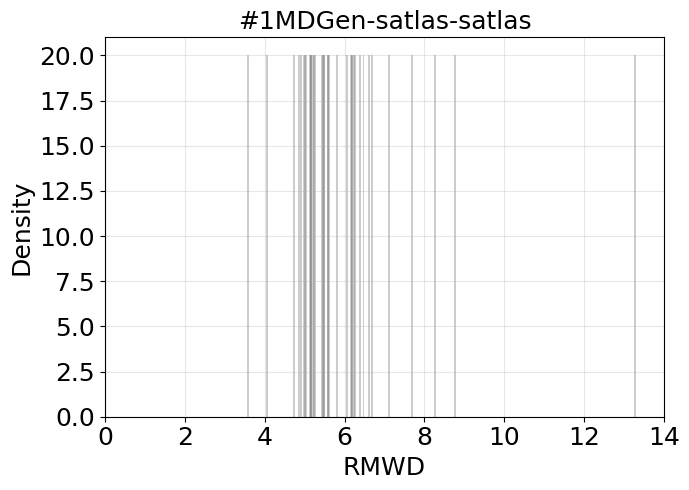

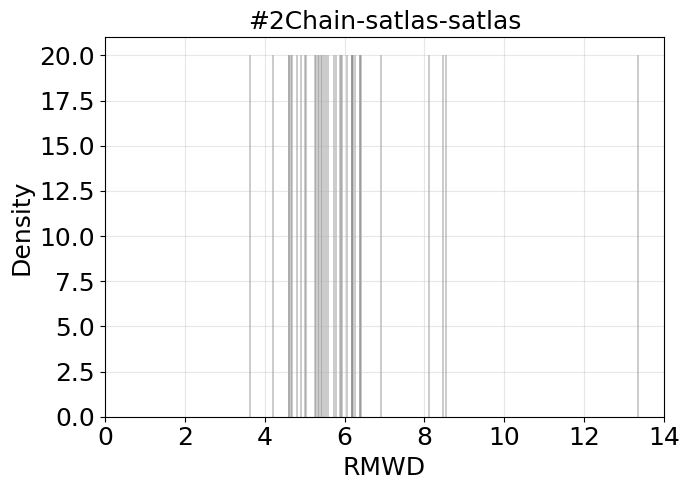

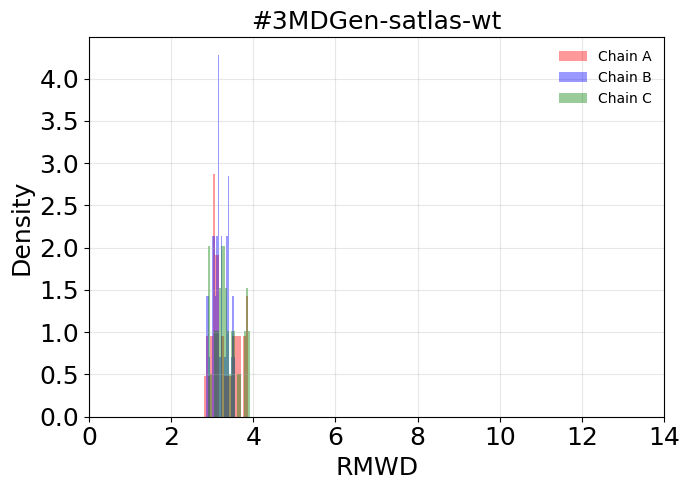

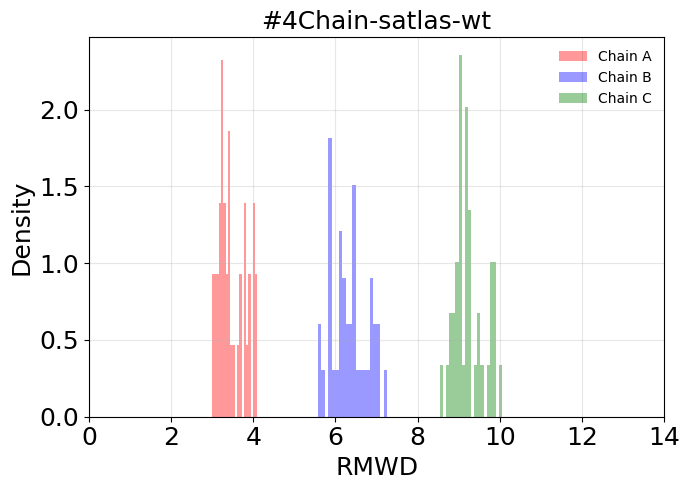

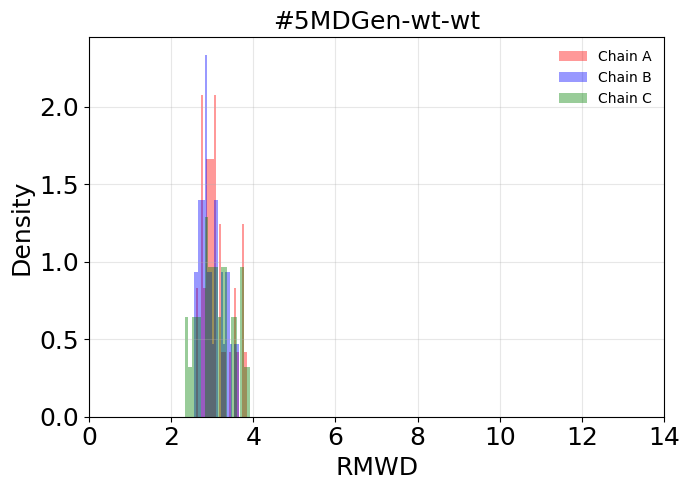

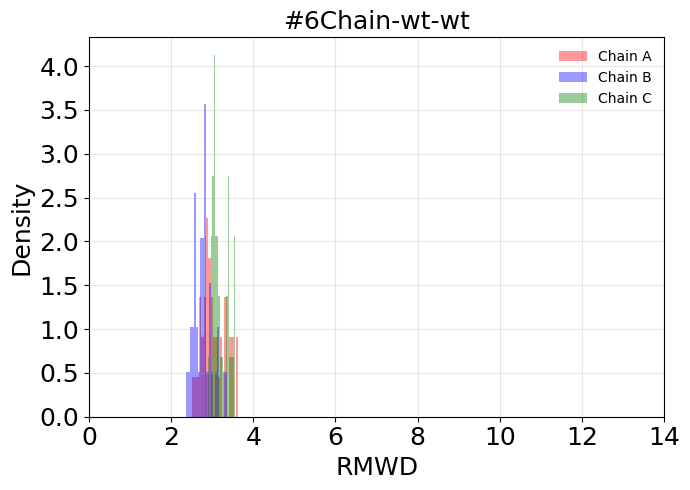

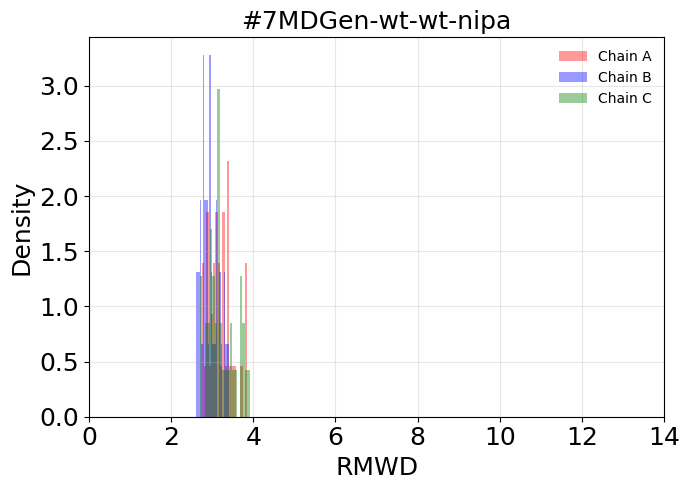

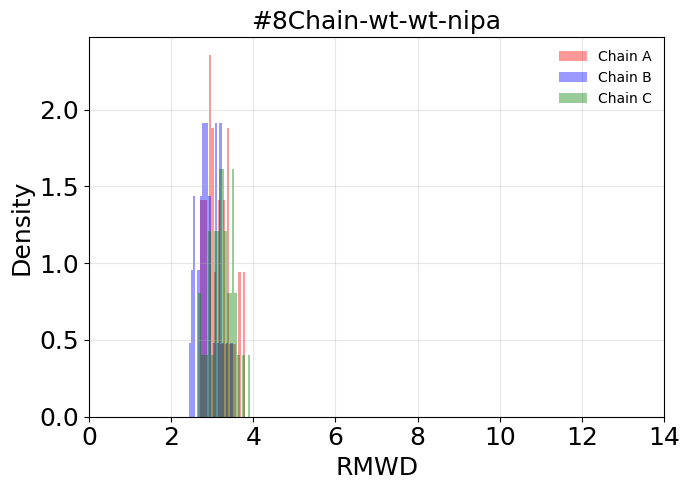

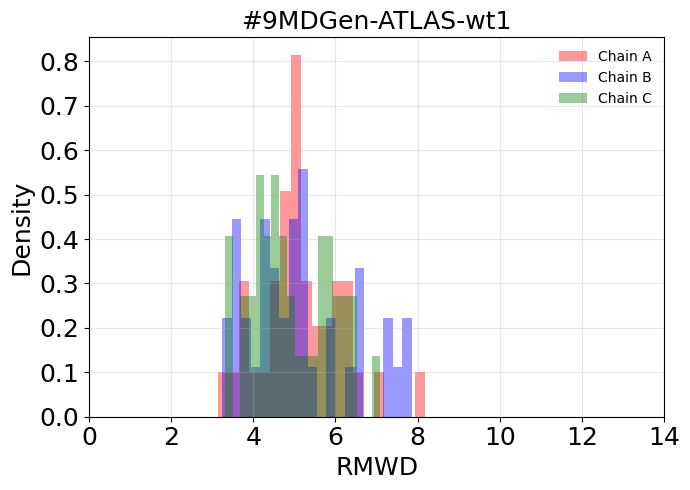

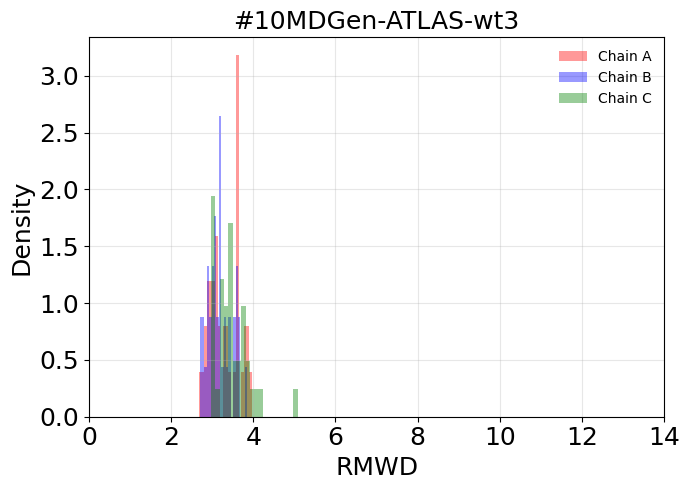

In [61]:
#1 Maai
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_satlas/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_satlas/analysis/Maai-rmwd.png'
title='#1MDGen-satlas-satlas'
plot_w2_distribution(pkl_path, out_png, title,legend_bool=False)

#2 Caai
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_satlas/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_satlas/analysis/Caai-rmwd.png'
title='#2Chain-satlas-satlas'
plot_w2_distribution(pkl_path, out_png, title,legend_bool=False)

#3 Mawi
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_wt/analysis/Mawi-rmwd.png'
title='#3MDGen-satlas-wt'
plot_w2_distribution(pkl_path, out_png, title)

#4 Cawi
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_wt/analysis/Cawi-rmwd.png'
title='#4Chain-satlas-wt'
plot_w2_distribution(pkl_path, out_png, title)

#5 Mwwi
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_wt-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_wt-test_wt/analysis/Mwwi-rmwd.png'
title='#5MDGen-wt-wt'
plot_w2_distribution(pkl_path, out_png, title)

#6 Cwwi
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_wt-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_wt-test_wt/analysis/Cwwi-rmwd.png'
title='#6Chain-wt-wt'
plot_w2_distribution(pkl_path, out_png, title)

#7 Mwwn 
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen-nipa/train_wt-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen-nipa/train_wt-test_wt/analysis/Mwwn-rmwd.png'
title='#7MDGen-wt-wt-nipa'
plot_w2_distribution(pkl_path, out_png, title)

#8 Cwwn
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain-nipa/train_wt-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain-nipa/train_wt-test_wt/analysis/Cwwn-rmwd.png'
title='#8Chain-wt-wt-nipa'
plot_w2_distribution(pkl_path, out_png, title)

#9 MAwi1
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt1/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt1/analysis/MAwi1-rmwd.png'
title='#9MDGen-ATLAS-wt1'
plot_w2_distribution(pkl_path, out_png, title)

#10 MAwi3
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt3/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt3/analysis/MAwi3-rmwd.png'
title='#10MDGen-ATLAS-wt3'
plot_w2_distribution(pkl_path, out_png, title)

### MD PCA W2 dist

In [62]:
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def analyze_data(data):
    rows = []
    for name, out in data.items():
        # 相容舊版 key
        if 'EMD,ref' not in out:
            if 'EMD-2,ref' in out:
                out['EMD,ref'] = out['EMD-2,ref']
            else:
                continue

        rows.append({
            'name': name,
            'md_pca_w2': out['EMD,ref']['ref|af'],
        })

    df = pd.DataFrame(rows).set_index('name')
    df['chain'] = df.index.str.split('-').str[-1]
    return df


def plot_md_pca_w2_distribution(pkl_path, out_png, title, legend_bool=True):
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        df = analyze_data(data)

    color_map = {
        'A': 'red',
        'B': 'blue',
        'C': 'green'
    }

    plt.figure(figsize=(7, 5))

    for chain, group in df.groupby('chain'):
        plt.hist(
            group['md_pca_w2'],
            bins=20,
            alpha=0.4,
            label=f'Chain {chain}',
            color=color_map.get(chain, 'gray'),
            density=True
        )

    plt.xlabel('MD PCA W2', fontsize=18)
    plt.ylabel('Density', fontsize=18)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.xlim(0,10)
    plt.title(title, fontsize=18)
    if legend_bool:
        plt.legend(frameon=False)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.show()

    print(df.groupby('chain')['md_pca_w2'].describe())

In [ ]:
#1 Maai
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_satlas/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_satlas/analysis/Maai-MDPCAW2.png'
title='#1MDGen-satlas-satlas'
plot_md_pca_w2_distribution(pkl_path, out_png, title,legend_bool=False)

#2 Caai
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_satlas/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_satlas/analysis/Caai-MDPCAW2.png'
title='#2Chain-satlas-satlas'
plot_md_pca_w2_distribution(pkl_path, out_png, title,legend_bool=False)

#3 Mawi
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_wt/analysis/Mawi-MDPCAW2.png'
title='#3MDGen-satlas-wt'
plot_md_pca_w2_distribution(pkl_path, out_png, title)

#4 Cawi
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_wt/analysis/Cawi-MDPCAW2.png'
title='#4Chain-satlas-wt'
plot_md_pca_w2_distribution(pkl_path, out_png, title)

#5 Mwwi
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_wt-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_wt-test_wt/analysis/Mwwi-MDPCAW2.png'
title='#5MDGen-wt-wt'
plot_md_pca_w2_distribution(pkl_path, out_png, title)

#6 Cwwi
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_wt-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_wt-test_wt/analysis/Cwwi-MDPCAW2.png'
title='#6Chain-wt-wt'
plot_md_pca_w2_distribution(pkl_path, out_png, title)

#7 Mwwn 
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen-nipa/train_wt-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen-nipa/train_wt-test_wt/analysis/Mwwn-MDPCAW2.png'
title='#7MDGen-wt-wt-nipa'
plot_md_pca_w2_distribution(pkl_path, out_png, title)

#8 Cwwn
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain-nipa/train_wt-test_wt/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain-nipa/train_wt-test_wt/analysis/Cwwn-MDPCAW2.png'
title='#8Chain-wt-wt-nipa'
plot_md_pca_w2_distribution(pkl_path, out_png, title)

#9 MAwi1
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt1/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt1/analysis/MAwi1-MDPCAW2.png'
title='#9MDGen-ATLAS-wt1'
plot_md_pca_w2_distribution(pkl_path, out_png, title)

#10 MAwi3
pkl_path = '/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt3/pkl/out.pkl'
out_png = '/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt3/analysis/MAwi3-MDPCAW2.png'
title='#10MDGen-ATLAS-wt3'
plot_md_pca_w2_distribution(pkl_path, out_png, title)

## unit height

In [3]:
import numpy as np
import MDAnalysis as mda
import matplotlib.pyplot as plt


def unh_distribution_md_vs_mdgen(
    pdb_list_md,
    xtc_list_md,
    pdb_list_mdgen,
    xtc_list_mdgen,
    output,title,
    triplet_number=10,
    last_n_frames=100,
    triplet_offset=1,
    stride_md=40,
    stride_mdgen=1,
    bins=50,
    density=True,
    figsize=(6, 4),
    use_triplet_center=True,
    return_data=False,
):
    """
    比較 MD 與 MDGen 的 unit height distribution。
    只計算中心 triplet 與 triplet_number + triplet_offset 之間的距離。

    Parameters
    ----------
    pdb_list_md : list[str]
        MD 的三條鏈 pdb 路徑 [A, B, C]
    xtc_list_md : list[str]
        MD 的三條鏈 xtc 路徑 [A, B, C]
    pdb_list_mdgen : list[str]
        MDGen 的三條鏈 pdb 路徑 [A, B, C]
    xtc_list_mdgen : list[str]
        MDGen 的三條鏈 xtc 路徑 [A, B, C]
    output : str
        輸出圖片檔名
    triplet_number : int
        中心 triplet 編號（相對於目前這份局部 pdb 的 triplet 編號）
    last_n_frames : int
        最後要取幾個 frame 點
        注意：
        - 對 MD 而言，若 stride_md=40，則會從最後 last_n_frames*40 frames 中每隔 40 取 1 個
        - 對 MDGen 而言，若 stride_mdgen=1，則就是最後 100 個 frame
    triplet_offset : int
        要看的相對位置，預設 1 表示只看中心與下一個 triplet 的距離
    stride_md : int
        MD 使用的 stride，預設 40
    stride_mdgen : int
        MDGen 使用的 stride，預設 1
    bins : int
        histogram bins
    density : bool
        是否畫 normalized histogram
    figsize : tuple
        圖大小
    use_triplet_center : bool
        True: 每個 triplet 用 3 個 residues 一起算中心
        False: 每個 triplet 只用第一個 residue
    return_data : bool
        是否回傳 md 與 mdgen 的數值

    Returns
    -------
    md_vals, mdgen_vals : np.ndarray
        若 return_data=True，回傳兩組 unit height 數值
    """

    def _calc_one_pair_distribution(
        pdb_list,
        xtc_list,
        triplet_number,
        triplet_offset,
        last_n_frames,
        stride,
        use_triplet_center,
    ):
        if len(pdb_list) != 3 or len(xtc_list) != 3:
            raise ValueError("每組 pdb_list / xtc_list 都必須有 3 個元素。")

        uA = mda.Universe(pdb_list[0], xtc_list[0])
        uB = mda.Universe(pdb_list[1], xtc_list[1])
        uC = mda.Universe(pdb_list[2], xtc_list[2])

        nA = uA.trajectory.n_frames
        nB = uB.trajectory.n_frames
        nC = uC.trajectory.n_frames
        if not (nA == nB == nC):
            raise ValueError(f"三條鏈 frame 數不同: A={nA}, B={nB}, C={nC}")

        resids_A = np.sort(np.unique(uA.select_atoms("protein").resids))
        resids_B = np.sort(np.unique(uB.select_atoms("protein").resids))
        resids_C = np.sort(np.unique(uC.select_atoms("protein").resids))

        if len(resids_A) < 3 or len(resids_B) < 3 or len(resids_C) < 3:
            raise ValueError("至少有一條鏈蛋白 residue 數少於 3，無法定義 triplet。")

        n_triplets_A = len(resids_A) // 3
        n_triplets_B = len(resids_B) // 3
        n_triplets_C = len(resids_C) // 3
        n_triplets = min(n_triplets_A, n_triplets_B, n_triplets_C)

        t1 = triplet_number
        t2 = triplet_number + triplet_offset

        if t1 < 1 or t1 > n_triplets:
            raise ValueError(f"triplet_number={t1} 超出範圍，可用範圍是 1 ~ {n_triplets}")
        if t2 < 1 or t2 > n_triplets:
            raise ValueError(
                f"triplet_number + triplet_offset = {t2} 超出範圍，可用範圍是 1 ~ {n_triplets}"
            )

        def _select_triplet_group(universe, resid_array, t_idx, use_triplet_center):
            start0 = (t_idx - 1) * 3

            if use_triplet_center:
                chosen = resid_array[start0:start0 + 3]
                sel = "protein and (" + " or ".join([f"resid {r}" for r in chosen]) + ")"
            else:
                chosen = [resid_array[start0]]
                sel = f"protein and resid {chosen[0]}"

            ag = universe.select_atoms(sel)
            return ag

        gA1 = _select_triplet_group(uA, resids_A, t1, use_triplet_center)
        gB1 = _select_triplet_group(uB, resids_B, t1, use_triplet_center)
        gC1 = _select_triplet_group(uC, resids_C, t1, use_triplet_center)

        gA2 = _select_triplet_group(uA, resids_A, t2, use_triplet_center)
        gB2 = _select_triplet_group(uB, resids_B, t2, use_triplet_center)
        gC2 = _select_triplet_group(uC, resids_C, t2, use_triplet_center)

        for g in [gA1, gB1, gC1, gA2, gB2, gC2]:
            if len(g) == 0:
                raise ValueError("選到空的 atom group，請檢查 pdb/xtc 或 resid 排法。")

        if stride < 1:
            raise ValueError("stride 必須 >= 1")

        n_frames = nA

        # 例如 last_n_frames=100, stride=40
        # 就從最後 4000 frames 範圍中，每隔 40 抽 1 個，共約 100 個點
        window_size = last_n_frames * stride
        start_frame = max(0, n_frames - window_size)
        frame_indices = np.arange(start_frame, n_frames, stride, dtype=int)

        # 如果因為總 frame 數不足，導致超過或少於預期，就只保留最後 last_n_frames 個抽樣點
        if len(frame_indices) > last_n_frames:
            frame_indices = frame_indices[-last_n_frames:]

        vals = []

        for frame_idx in frame_indices:
            uA.trajectory[frame_idx]
            uB.trajectory[frame_idx]
            uC.trajectory[frame_idx]

            c1A = gA1.center_of_geometry()
            c1B = gB1.center_of_geometry()
            c1C = gC1.center_of_geometry()
            center1 = (c1A + c1B + c1C) / 3.0

            c2A = gA2.center_of_geometry()
            c2B = gB2.center_of_geometry()
            c2C = gC2.center_of_geometry()
            center2 = (c2A + c2B + c2C) / 3.0

            dist = np.linalg.norm(center2 - center1)
            vals.append(dist)

        return np.asarray(vals, dtype=float)

    md_vals = _calc_one_pair_distribution(
        pdb_list=pdb_list_md,
        xtc_list=xtc_list_md,
        triplet_number=triplet_number,
        triplet_offset=triplet_offset,
        last_n_frames=last_n_frames,
        stride=stride_md,
        use_triplet_center=use_triplet_center,
    )

    mdgen_vals = _calc_one_pair_distribution(
        pdb_list=pdb_list_mdgen,
        xtc_list=xtc_list_mdgen,
        triplet_number=triplet_number,
        triplet_offset=triplet_offset,
        last_n_frames=last_n_frames,
        stride=stride_mdgen,
        use_triplet_center=use_triplet_center,
    )

    plt.figure(figsize=figsize)
    plt.hist(md_vals, bins=bins, density=density, alpha=0.5, label=f"MD (stride={stride_md})")
    plt.hist(mdgen_vals, bins=bins, density=density, alpha=0.5, label=f"MDGen (stride={stride_mdgen})")
    plt.xlim(5,9)
    plt.xlabel("Unit height (Å)")
    plt.ylabel("Probability density" if density else "Count")
    plt.title(f'{title}',fontsize=18
    )
    plt.legend()
    plt.tight_layout()
    plt.savefig(output, dpi=300)
    plt.close()

    print("===== unit height comparison =====")
    print(f"triplet pair   : {triplet_number} -> {triplet_number + triplet_offset}")
    print(f"MD frames      : {len(md_vals)} (stride={stride_md})")
    print(f"MD mean/std    : {md_vals.mean():.4f} / {md_vals.std():.4f}")
    print(f"MDGen frames   : {len(mdgen_vals)} (stride={stride_mdgen})")
    print(f"MDGen mean/std : {mdgen_vals.mean():.4f} / {mdgen_vals.std():.4f}")
    print(f"saved plot     : {output}")

    if return_data:
        return md_vals, mdgen_vals

In [ ]:
import numpy as np
import MDAnalysis as mda
import matplotlib.pyplot as plt
from MDAnalysis.analysis import align


def unh_distribution_md_vs_mdgen(
    pdb_list_md,
    xtc_list_md,
    pdb_list_mdgen,
    xtc_list_mdgen,
    output, title,
    triplet_number=10,
    last_n_frames=100,
    triplet_offset=1,
    stride_md=40,
    stride_mdgen=1,
    bins=50,
    density=True,
    figsize=(6, 4),
    use_triplet_center=True,
    return_data=False,
    align_selection="protein and backbone",
):
    """
    比較 MD 與 MDGen 的 unit height distribution。
    每個要分析的 frame 會先 align 到 MD 的 frame 0，再計算 unit height。
    """

    def _calc_one_pair_distribution(
        pdb_list,
        xtc_list,
        ref_pdb_list,
        ref_xtc_list,
        triplet_number,
        triplet_offset,
        last_n_frames,
        stride,
        use_triplet_center,
        align_selection,
    ):
        if len(pdb_list) != 3 or len(xtc_list) != 3:
            raise ValueError("每組 pdb_list / xtc_list 都必須有 3 個元素。")

        # 要分析的三條鏈
        uA = mda.Universe(pdb_list[0], xtc_list[0])
        uB = mda.Universe(pdb_list[1], xtc_list[1])
        uC = mda.Universe(pdb_list[2], xtc_list[2])

        # reference：固定用 MD 的 frame 0
        refA = mda.Universe(ref_pdb_list[0], ref_xtc_list[0])
        refB = mda.Universe(ref_pdb_list[1], ref_xtc_list[1])
        refC = mda.Universe(ref_pdb_list[2], ref_xtc_list[2])

        refA.trajectory[0]
        refB.trajectory[0]
        refC.trajectory[0]

        nA = uA.trajectory.n_frames
        nB = uB.trajectory.n_frames
        nC = uC.trajectory.n_frames
        if not (nA == nB == nC):
            raise ValueError(f"三條鏈 frame 數不同: A={nA}, B={nB}, C={nC}")

        resids_A = np.sort(np.unique(uA.select_atoms("protein").resids))
        resids_B = np.sort(np.unique(uB.select_atoms("protein").resids))
        resids_C = np.sort(np.unique(uC.select_atoms("protein").resids))

        if len(resids_A) < 3 or len(resids_B) < 3 or len(resids_C) < 3:
            raise ValueError("至少有一條鏈蛋白 residue 數少於 3，無法定義 triplet。")

        n_triplets_A = len(resids_A) // 3
        n_triplets_B = len(resids_B) // 3
        n_triplets_C = len(resids_C) // 3
        n_triplets = min(n_triplets_A, n_triplets_B, n_triplets_C)

        t1 = triplet_number
        t2 = triplet_number + triplet_offset

        if t1 < 1 or t1 > n_triplets:
            raise ValueError(f"triplet_number={t1} 超出範圍，可用範圍是 1 ~ {n_triplets}")
        if t2 < 1 or t2 > n_triplets:
            raise ValueError(
                f"triplet_number + triplet_offset = {t2} 超出範圍，可用範圍是 1 ~ {n_triplets}"
            )

        def _select_triplet_group(universe, resid_array, t_idx, use_triplet_center):
            start0 = (t_idx - 1) * 3

            if use_triplet_center:
                chosen = resid_array[start0:start0 + 3]
                sel = "protein and (" + " or ".join([f"resid {r}" for r in chosen]) + ")"
            else:
                chosen = [resid_array[start0]]
                sel = f"protein and resid {chosen[0]}"

            ag = universe.select_atoms(sel)
            return ag

        gA1 = _select_triplet_group(uA, resids_A, t1, use_triplet_center)
        gB1 = _select_triplet_group(uB, resids_B, t1, use_triplet_center)
        gC1 = _select_triplet_group(uC, resids_C, t1, use_triplet_center)

        gA2 = _select_triplet_group(uA, resids_A, t2, use_triplet_center)
        gB2 = _select_triplet_group(uB, resids_B, t2, use_triplet_center)
        gC2 = _select_triplet_group(uC, resids_C, t2, use_triplet_center)

        for g in [gA1, gB1, gC1, gA2, gB2, gC2]:
            if len(g) == 0:
                raise ValueError("選到空的 atom group，請檢查 pdb/xtc 或 resid 排法。")

        if stride < 1:
            raise ValueError("stride 必須 >= 1")

        # 檢查 alignment selection 是否能正常選到原子
        mobA = uA.select_atoms(align_selection)
        mobB = uB.select_atoms(align_selection)
        mobC = uC.select_atoms(align_selection)

        ref_selA = refA.select_atoms(align_selection)
        ref_selB = refB.select_atoms(align_selection)
        ref_selC = refC.select_atoms(align_selection)

        if len(mobA) == 0 or len(mobB) == 0 or len(mobC) == 0:
            raise ValueError(f"目前系統中 align_selection='{align_selection}' 選不到原子。")
        if len(ref_selA) == 0 or len(ref_selB) == 0 or len(ref_selC) == 0:
            raise ValueError(f"reference 中 align_selection='{align_selection}' 選不到原子。")

        n_frames = nA
        window_size = last_n_frames * stride
        start_frame = max(0, n_frames - window_size)
        frame_indices = np.arange(start_frame, n_frames, stride, dtype=int)

        if len(frame_indices) > last_n_frames:
            frame_indices = frame_indices[-last_n_frames:]

        vals = []

        for frame_idx in frame_indices:
            uA.trajectory[frame_idx]
            uB.trajectory[frame_idx]
            uC.trajectory[frame_idx]

            # ===== 先 align 到 MD 的 frame 0 =====
            align.alignto(uA, refA, select=align_selection)
            align.alignto(uB, refB, select=align_selection)
            align.alignto(uC, refC, select=align_selection)

            # ===== 再算 unit height =====
            c1A = gA1.center_of_geometry()
            c1B = gB1.center_of_geometry()
            c1C = gC1.center_of_geometry()
            center1 = (c1A + c1B + c1C) / 3.0

            c2A = gA2.center_of_geometry()
            c2B = gB2.center_of_geometry()
            c2C = gC2.center_of_geometry()
            center2 = (c2A + c2B + c2C) / 3.0

            dist = np.linalg.norm(center2 - center1)
            vals.append(dist)

        return np.asarray(vals, dtype=float)

    # MD：每個 frame 先 align 到 MD frame0
    md_vals = _calc_one_pair_distribution(
        pdb_list=pdb_list_md,
        xtc_list=xtc_list_md,
        ref_pdb_list=pdb_list_md,
        ref_xtc_list=xtc_list_md,
        triplet_number=triplet_number,
        triplet_offset=triplet_offset,
        last_n_frames=last_n_frames,
        stride=stride_md,
        use_triplet_center=use_triplet_center,
        align_selection=align_selection,
    )

    # MDGen：每個 frame 也 align 到 MD frame0
    mdgen_vals = _calc_one_pair_distribution(
        pdb_list=pdb_list_mdgen,
        xtc_list=xtc_list_mdgen,
        ref_pdb_list=pdb_list_md,
        ref_xtc_list=xtc_list_md,
        triplet_number=triplet_number,
        triplet_offset=triplet_offset,
        last_n_frames=last_n_frames,
        stride=stride_mdgen,
        use_triplet_center=use_triplet_center,
        align_selection=align_selection,
    )

    plt.figure(figsize=figsize)
    plt.hist(md_vals, bins=bins, density=density, alpha=0.5, label=f"MD (stride={stride_md})")
    plt.hist(mdgen_vals, bins=bins, density=density, alpha=0.5, label=f"MDGen (stride={stride_mdgen})")
    plt.xlim(5, 9)
    plt.xlabel("Unit height (Å)")
    plt.ylabel("Probability density" if density else "Count")
    plt.title(title, fontsize=18)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output, dpi=300)
    plt.close()

    print("===== unit height comparison =====")
    print(f"triplet pair   : {triplet_number} -> {triplet_number + triplet_offset}")
    print(f"alignment ref  : MD frame 0")
    print(f"align selection: {align_selection}")
    print(f"MD frames      : {len(md_vals)} (stride={stride_md})")
    print(f"MD mean/std    : {md_vals.mean():.4f} / {md_vals.std():.4f}")
    print(f"MDGen frames   : {len(mdgen_vals)} (stride={stride_mdgen})")
    print(f"MDGen mean/std : {mdgen_vals.mean():.4f} / {mdgen_vals.std():.4f}")
    print(f"saved plot     : {output}")

    if return_data:
        return md_vals, mdgen_vals

/home/jeff/miniconda3/envs/mdgen/lib/python3.10/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [ ]:
#3
pdb_list_md = [f'/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/pdbxtc/chain-r1/wt-62-{k}.pdb' for k in ['A', 'B', 'C']]
xtc_list_md = [f'/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/pdbxtc/chain-r1/wt-62-{k}.xtc' for k in ['A', 'B', 'C']]
pdb_list_mdgen = [f'/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_wt/inference/wt-62-{k}.pdb' for k in ['A', 'B', 'C']]
xtc_list_mdgen = [f'/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_wt/inference/wt-62-{k}.xtc' for k in ['A', 'B', 'C']]
output = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_wt/analysis/Mawi-62-unh.png'
title = '#3-MDGen-satlas-wt'
unh_distribution_md_vs_mdgen(
    pdb_list_md,
    xtc_list_md,
    pdb_list_mdgen,
    xtc_list_mdgen,
    output,title)

#4
pdb_list_md = [f'/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/pdbxtc/chain-r1/wt-62-{k}.pdb' for k in ['A', 'B', 'C']]
xtc_list_md = [f'/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/pdbxtc/chain-r1/wt-62-{k}.xtc' for k in ['A', 'B', 'C']]
pdb_list_mdgen = [f'/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_wt/inference/wt-62-{k}.pdb' for k in ['A', 'B', 'C']]
xtc_list_mdgen = [f'/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_wt/inference/wt-62-{k}.xtc' for k in ['A', 'B', 'C']]
output = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_wt/analysis/Cawi-62-unh.png'
title = '#4-Chain-satlas-wt'
unh_distribution_md_vs_mdgen(
    pdb_list_md,
    xtc_list_md,
    pdb_list_mdgen,
    xtc_list_mdgen,
    output,title)

#5
pdb_list_md = [f'/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/pdbxtc/chain-r1/wt-62-{k}.pdb' for k in ['A', 'B', 'C']]
xtc_list_md = [f'/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/pdbxtc/chain-r1/wt-62-{k}.xtc' for k in ['A', 'B', 'C']]
pdb_list_mdgen = [f'/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_wt-test_wt/inference/wt-62-{k}.pdb' for k in ['A', 'B', 'C']]
xtc_list_mdgen = [f'/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_wt-test_wt/inference/wt-62-{k}.xtc' for k in ['A', 'B', 'C']]
output = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_wt-test_wt/analysis/Mwwi-62-unh.png'
title = '#5-MDGen-wt-wt'
unh_distribution_md_vs_mdgen(
    pdb_list_md,
    xtc_list_md,
    pdb_list_mdgen,
    xtc_list_mdgen,
    output,title)

#6
pdb_list_md = [f'/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/pdbxtc/chain-r1/wt-62-{k}.pdb' for k in ['A', 'B', 'C']]
xtc_list_md = [f'/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/pdbxtc/chain-r1/wt-62-{k}.xtc' for k in ['A', 'B', 'C']]
pdb_list_mdgen = [f'/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_wt-test_wt/inference/wt-62-{k}.pdb' for k in ['A', 'B', 'C']]
xtc_list_mdgen = [f'/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_wt-test_wt/inference/wt-62-{k}.xtc' for k in ['A', 'B', 'C']]
output = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_wt-test_wt/analysis/Cwwi-62-unh.png'
title = '#6-Chain-wt-wt'
unh_distribution_md_vs_mdgen(
    pdb_list_md,
    xtc_list_md,
    pdb_list_mdgen,
    xtc_list_mdgen,
    output,title)

#7
pdb_list_md = [f'/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/pdbxtc/chain-r1/wt-62-{k}.pdb' for k in ['A', 'B', 'C']]
xtc_list_md = [f'/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/pdbxtc/chain-r1/wt-62-{k}.xtc' for k in ['A', 'B', 'C']]
pdb_list_mdgen = [f'/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen-nipa/train_wt-test_wt/inference/wt-62-{k}.pdb' for k in ['A', 'B', 'C']]
xtc_list_mdgen = [f'/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen-nipa/train_wt-test_wt/inference/wt-62-{k}.xtc' for k in ['A', 'B', 'C']]
output = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen-nipa/train_wt-test_wt/analysis/Mwwn-62-unh.png'
title = '#7-MDGen-wt-wt-nipa'
unh_distribution_md_vs_mdgen(
    pdb_list_md,
    xtc_list_md,
    pdb_list_mdgen,
    xtc_list_mdgen,
    output,title)

#8
pdb_list_md = [f'/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/pdbxtc/chain-r1/wt-62-{k}.pdb' for k in ['A', 'B', 'C']]
xtc_list_md = [f'/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/pdbxtc/chain-r1/wt-62-{k}.xtc' for k in ['A', 'B', 'C']]
pdb_list_mdgen = [f'/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain-nipa/train_wt-test_wt/inference/wt-62-{k}.pdb' for k in ['A', 'B', 'C']]
xtc_list_mdgen = [f'/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain-nipa/train_wt-test_wt/inference/wt-62-{k}.xtc' for k in ['A', 'B', 'C']]
output = '/mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain-nipa/train_wt-test_wt/analysis/Cwwn-62-unh.png'
title = '#8-Chain-wt-wt-nipa'
unh_distribution_md_vs_mdgen(
    pdb_list_md,
    xtc_list_md,
    pdb_list_mdgen,
    xtc_list_mdgen,
    output,title)

#9
pdb_list_md = [f'/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/pdbxtc/chain-r1/wt-62-{k}.pdb' for k in ['A', 'B', 'C']]
xtc_list_md = [f'/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/pdbxtc/chain-r1/wt-62-{k}.xtc' for k in ['A', 'B', 'C']]
pdb_list_mdgen = [f'/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt1/inference/wt-62-{k}.pdb' for k in ['A', 'B', 'C']]
xtc_list_mdgen = [f'/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt1/inference/wt-62-{k}.xtc' for k in ['A', 'B', 'C']]
output = '/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt1/analysis/MAwi1-62-unh.png'
title = '#9-MDGen-ATLAS-wt1'
unh_distribution_md_vs_mdgen(
    pdb_list_md,
    xtc_list_md,
    pdb_list_mdgen,
    xtc_list_mdgen,
    output,title)

#10
pdb_list_md = [f'/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/pdbxtc/chain-r1/wt-62-{k}.pdb' for k in ['A', 'B', 'C']]
xtc_list_md = [f'/mnt/hdd/jeff/MDGen/data/dataset/wt-collagen/raw/100ns/pdbxtc/chain-r1/wt-62-{k}.xtc' for k in ['A', 'B', 'C']]
pdb_list_mdgen = [f'/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt3/inference/wt-62-{k}.pdb' for k in ['A', 'B', 'C']]
xtc_list_mdgen = [f'/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt3/inference/wt-62-{k}.xtc' for k in ['A', 'B', 'C']]
output = '/mnt/hdd/jeff/MDGen/data/experiment/github/train_atlas-test_wt3/analysis/MAwi3-62-unh.png'
title = '#10-MDGen-ATLAS-wt3'
unh_distribution_md_vs_mdgen(
    pdb_list_md,
    xtc_list_md,
    pdb_list_mdgen,
    xtc_list_mdgen,
    output,title)

===== unit height comparison =====
triplet pair   : 10 -> 11
alignment ref  : MD frame 0
align selection: protein and backbone
MD frames      : 100 (stride=40)
MD mean/std    : 7.2238 / 0.5585
MDGen frames   : 100 (stride=1)
MDGen mean/std : 6.0265 / 0.3292
saved plot     : /mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen/train_satlas-test_wt/analysis/Mawi-62-unh.png
===== unit height comparison =====
triplet pair   : 10 -> 11
alignment ref  : MD frame 0
align selection: protein and backbone
MD frames      : 100 (stride=40)
MD mean/std    : 7.2238 / 0.5585
MDGen frames   : 100 (stride=1)
MDGen mean/std : 6.7607 / 0.5244
saved plot     : /mnt/hdd/jeff/MDGen/data/experiment/scratch/mdgen_chain/train_satlas-test_wt/analysis/Cawi-62-unh.png
===== unit height comparison =====
triplet pair   : 10 -> 11
alignment ref  : MD frame 0
align selection: protein and backbone
MD frames      : 100 (stride=40)
MD mean/std    : 7.2238 / 0.5585
MDGen frames   : 100 (stride=1)
MDGen mean/std : 5.5877 / 0